# 🔥 Multimodal Consistency Reasoning Framework — IMPROVED VERSION
## Key upgrades applied:
- ✅ **400 samples/class** (was 100) — bigger training data
- ✅ **RoBERTa-base** text encoder (was DistilBERT) — stronger language model
- ✅ **ResNet-50** image encoder (was ResNet-18) — deeper vision backbone
- ✅ **Cosine LR scheduler + early stopping** (was fixed LR, no stopping)
- ✅ **Stronger image augmentation** (random crop, color jitter, rotation)
- ✅ **XGBoost** metadata model (was RandomForest)
- ✅ **Learned MLP fusion** (was fixed alpha=0.7)
- ✅ **Gradient clipping** to stabilise training


# STEP 1 — Environment Setup

In [1]:
import os, sys, platform, torch

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("⚠️  Running on CPU — training will be slow. Enable GPU in Runtime > Change runtime type")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
CUDA version: 12.8


# STEP 2 — Install Libraries

In [2]:
!pip -q install transformers datasets timm pillow scikit-learn matplotlib pandas tqdm xgboost sentence-transformers easyocr kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 15.1 MB/s eta 0:00:00


# STEP 3 — Seeds & Project Folders

In [3]:
import random, numpy as np, torch
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

BASE_DIR   = Path("/content/fake_news_project")
DATA_DIR   = BASE_DIR / "data"
CACHE_DIR  = BASE_DIR / "cache"
OUTPUT_DIR = BASE_DIR / "outputs"
CKPT_DIR   = BASE_DIR / "checkpoints"

for d in [BASE_DIR, DATA_DIR, CACHE_DIR, OUTPUT_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Seed set to:", SEED)


Device: cuda
Seed set to: 42


# STEP 4 — Download Fakeddit Dataset

In [4]:
import kagglehub
dataset_path = kagglehub.dataset_download("vanshikavmittal/fakeddit-dataset")
print("Dataset at:", dataset_path)


100%|██████████| 72.8M/72.8M [00:05<00:00, 13.7MB/s]

Extracting files...


Dataset at: /root/.cache/kagglehub/datasets/vanshikavmittal/fakeddit-dataset/versions/4


# STEP 5 — Load Train / Val / Test TSV Files

In [5]:
import pandas as pd
from pathlib import Path

FAKEDDIT_BASE = Path(dataset_path) / "multimodal_only_samples"

train_df = pd.read_csv(FAKEDDIT_BASE / "multimodal_train.tsv",        sep="\t")
valid_df = pd.read_csv(FAKEDDIT_BASE / "multimodal_validate.tsv",     sep="\t")
test_df  = pd.read_csv(FAKEDDIT_BASE / "multimodal_test_public.tsv",  sep="\t")

print("Train:", train_df.shape, "| Valid:", valid_df.shape, "| Test:", test_df.shape)
print("Columns:", train_df.columns.tolist())


Train: (564000, 16) | Valid: (59342, 16) | Test: (59319, 16)
Columns: ['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']


# STEP 6 — Create Balanced Dataset (400 per class)

In [6]:
# ✅ UPGRADE: 400 per class (was 100) — more data = better generalisation
SAMPLES_PER_CLASS = 500   # initial pool

debug_df = (
    train_df.groupby("6_way_label", group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), SAMPLES_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

print("Debug pool shape:", debug_df.shape)
print(debug_df["6_way_label"].value_counts().sort_index())


Debug pool shape: (3000, 16)
6_way_label
0    500
1    500
2    500
3    500
4    500
5    500
Name: count, dtype: int64


/tmp/ipykernel_2283/366028243.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), SAMPLES_PER_CLASS), random_state=42))


# STEP 7 — Download & Cache Images

In [7]:
import time, requests
from io import BytesIO
from PIL import Image, UnidentifiedImageError

IMAGE_CACHE_DIR = BASE_DIR / "data" / "image_cache"
IMAGE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def download_and_cache_image(row, cache_dir=IMAGE_CACHE_DIR, timeout=15):
    sample_id = str(row["id"])
    image_url = row["image_url"]

    if pd.isna(image_url) or not str(image_url).strip():
        return {"status": "missing_url", "local_path": None, "error": "missing url"}

    out_path = cache_dir / f"{sample_id}.jpg"
    if out_path.exists():
        return {"status": "ok", "local_path": str(out_path), "error": None}

    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        resp = requests.get(image_url, headers=headers, timeout=timeout)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img.save(out_path, format="JPEG", quality=95)
        return {"status": "ok", "local_path": str(out_path), "error": None}
    except requests.RequestException as e:
        return {"status": "request_error", "local_path": None, "error": str(e)}
    except (UnidentifiedImageError, OSError) as e:
        return {"status": "bad_image", "local_path": None, "error": str(e)}

print("Image download function ready.")


Image download function ready.


In [8]:
from tqdm.auto import tqdm

# ✅ UPGRADE: 400 per class (was 100)
CACHE_SAMPLES_PER_CLASS = 400

work_parts = []
for label, group in debug_df.groupby("6_way_label"):
    work_parts.append(group.sample(n=min(len(group), CACHE_SAMPLES_PER_CLASS), random_state=42))

work_df = pd.concat(work_parts).reset_index(drop=True)
print("Work subset:", work_df.shape)

cache_results = []
for _, row in tqdm(work_df.iterrows(), total=len(work_df)):
    result = download_and_cache_image(row)
    cache_results.append({"id": row["id"], "status": result["status"],
                           "local_image_path": result["local_path"]})

cache_results_df = pd.DataFrame(cache_results)
print(cache_results_df["status"].value_counts())

work_df = work_df.merge(cache_results_df[["id","status","local_image_path"]], on="id", how="left")
work_df_ok = work_df[work_df["status"] == "ok"].copy().reset_index(drop=True)

print("\nUsable rows:", len(work_df_ok))
print(work_df_ok["6_way_label"].value_counts().sort_index())


Work subset: (2400, 16)


  0%|          | 0/2400 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


status
ok               2286
request_error     108
missing_url         5
bad_image           1
Name: count, dtype: int64

Usable rows: 2286
6_way_label
0    364
1    374
2    375
3    383
4    396
5    394
Name: count, dtype: int64


# STEP 8 — Train / Validation Split

In [9]:
from sklearn.model_selection import train_test_split

train_df_main, val_df_main = train_test_split(
    work_df_ok, test_size=0.2, random_state=42,
    stratify=work_df_ok["6_way_label"]
)
train_df_main = train_df_main.reset_index(drop=True)
val_df_main   = val_df_main.reset_index(drop=True)

print("Train:", train_df_main.shape, "| Val:", val_df_main.shape)
print("\nTrain class counts:")
print(train_df_main["6_way_label"].value_counts().sort_index())


Train: (1828, 18) | Val: (458, 18)

Train class counts:
6_way_label
0    291
1    299
2    300
3    306
4    317
5    315
Name: count, dtype: int64


# STEP 9 — Tokenizer (RoBERTa) & Image Transforms

In [10]:
from transformers import AutoTokenizer
from torchvision import transforms

# ✅ UPGRADE: RoBERTa-base (was DistilBERT)
TEXT_MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
print("Tokenizer:", TEXT_MODEL_NAME)

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# ✅ UPGRADE: stronger augmentation (ColorJitter, RandomRotation, RandomResizedCrop)
train_image_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Image transforms ready.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer: roberta-base
Image transforms ready.


# STEP 10 — Multimodal Dataset Class

In [11]:
from torch.utils.data import Dataset
import torch

MAX_TEXT_LEN = 128

class FakedditMultimodalDataset(Dataset):
    def __init__(self, df, tokenizer, image_transform=None, max_text_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.max_text_len = max_text_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text  = str(row["clean_title"])
        label = int(row["6_way_label"])
        image_path = row["local_image_path"]

        enc = self.tokenizer(text, truncation=True, padding="max_length",
                             max_length=self.max_text_len, return_tensors="pt")
        image = Image.open(image_path).convert("RGB")
        if self.image_transform:
            image = self.image_transform(image)

        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "text":  text,
            "id":    row["id"]
        }

train_dataset = FakedditMultimodalDataset(train_df_main, tokenizer, train_image_transform, MAX_TEXT_LEN)
val_dataset   = FakedditMultimodalDataset(val_df_main,   tokenizer, val_image_transform,   MAX_TEXT_LEN)
print("Train:", len(train_dataset), "| Val:", len(val_dataset))


Train: 1828 | Val: 458


# STEP 11 — DataLoaders

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))


Train batches: 115 | Val batches: 29


# STEP 12 — Improved Multimodal Model (RoBERTa + ResNet-50)

In [13]:
import torch.nn as nn
from transformers import AutoModel
from torchvision import models

class ImprovedMultimodalModel(nn.Module):
    def __init__(self, text_model_name="roberta-base", num_classes=6, dropout=0.3):
        super().__init__()

        # ✅ UPGRADE: RoBERTa-base text encoder
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_hidden_size  = self.text_encoder.config.hidden_size   # 768

        # ✅ UPGRADE: ResNet-50 image encoder (was ResNet-18)
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        image_hidden_size = resnet.fc.in_features   # 2048
        resnet.fc = nn.Identity()
        self.image_encoder = resnet

        fusion_dim = text_hidden_size + image_hidden_size  # 768 + 2048 = 2816

        # ✅ UPGRADE: deeper classifier head
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask, image):
        text_out  = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = text_out.last_hidden_state[:, 0, :]   # CLS token
        img_feat  = self.image_encoder(image)
        fused     = torch.cat([text_feat, img_feat], dim=1)
        return self.classifier(fused)

model = ImprovedMultimodalModel(text_model_name=TEXT_MODEL_NAME, num_classes=6).to(device)
print("Model created: RoBERTa-base + ResNet-50 fusion")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 51.9MB/s]


Model created: RoBERTa-base + ResNet-50 fusion
Trainable parameters: 151,568,198


# STEP 13 — Loss, Optimizer & LR Scheduler

In [14]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

# Weighted cross-entropy for class imbalance
classes = np.array(sorted(train_df_main["6_way_label"].unique()))
weights = compute_class_weight("balanced", classes=classes, y=train_df_main["6_way_label"].values)
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ✅ UPGRADE: separate LR for backbone vs head
optimizer = AdamW([
    {"params": model.text_encoder.parameters(),  "lr": 2e-5},
    {"params": model.image_encoder.parameters(), "lr": 1e-4},
    {"params": model.classifier.parameters(),    "lr": 1e-4},
], weight_decay=1e-2)

# ✅ UPGRADE: cosine decay scheduler with warmup
NUM_EPOCHS   = 20
NUM_WARMUP   = len(train_loader)            # 1 epoch warmup
NUM_TRAINING = NUM_EPOCHS * len(train_loader)

scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=NUM_WARMUP, num_training_steps=NUM_TRAINING
)

print(f"Optimizer ready | Epochs: {NUM_EPOCHS} | Warmup steps: {NUM_WARMUP}")


Optimizer ready | Epochs: 20 | Warmup steps: 115


# STEP 14 — Training & Evaluation Functions

In [15]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report

MAX_GRAD_NORM = 1.0   # gradient clipping

def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        imgs  = batch["image"].to(device)
        labels= batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(ids, mask, imgs)
        loss   = criterion(logits, labels)
        loss.backward()

        # ✅ UPGRADE: gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

    return running_loss / total, correct / total


def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            imgs  = batch["image"].to(device)
            labels= batch["label"].to(device)

            logits = model(ids, mask, imgs)
            loss   = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    n = len(all_labels)
    return (running_loss / n,
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro"),
            all_labels, all_preds)

print("Train/eval functions ready.")


Train/eval functions ready.


# STEP 15 — Training Loop with Early Stopping

In [16]:
label_names = {0:"TRUE", 1:"SATIRE", 2:"FALSE_CONNECTION",
               3:"IMPOSTER", 4:"MANIPULATED", 5:"MISLEADING"}
target_names = [label_names[i] for i in range(6)]

history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[], "val_f1":[]}

best_val_f1  = -1.0
best_model_path = CKPT_DIR / "best_improved_model.pt"

# ✅ UPGRADE: early stopping
PATIENCE    = 5
no_improve  = 0

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*55}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print('='*55)

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    vl_loss, vl_acc, vl_f1, y_true, y_pred = evaluate_model(model, val_loader, criterion, device)

    history["train_loss"].append(tr_loss);  history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss);    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    print(f"Train → Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}")
    print(f"Val   → Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  F1: {vl_f1:.4f}")

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✅ New best saved (F1={best_val_f1:.4f})")
        no_improve = 0
    else:
        no_improve += 1
        print(f"  ⏳ No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print("  ⛔ Early stopping triggered.")
            break

print("\n🏁 Training finished. Best Val F1:", round(best_val_f1, 4))



Epoch 1/20


Training:   0%|          | 0/115 [00:00<?, ?it/s]

Validation:   0%|          | 0/29 [00:00<?, ?it/s]

Train → Loss: 1.7004  Acc: 0.2872
Val   → Loss: 1.2845  Acc: 0.5306  F1: 0.4864
  ✅ New best saved (F1=0.4864)

Epoch 2/20


Training:   0%|          | 0/115 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/29 [00:00<?, ?it/s]

Train → Loss: 0.0495  Acc: 0.9814
Val   → Loss: 1.5193  Acc: 0.6900  F1: 0.6805
  ⏳ No improvement (4/5)

Epoch 10/20


Training:   0%|          | 0/115 [00:00<?, ?it/s]

Validation:   0%|          | 0/29 [00:00<?, ?it/s]

Train → Loss: 0.0471  Acc: 0.9869
Val   → Loss: 1.5703  Acc: 0.6856  F1: 0.6844
  ⏳ No improvement (5/5)
  ⛔ Early stopping triggered.

🏁 Training finished. Best Val F1: 0.7077


# STEP 16 — Load Best Model & Classification Report

In [17]:
best_model = ImprovedMultimodalModel(text_model_name=TEXT_MODEL_NAME, num_classes=6).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
print("Best model loaded.")

_, vl_acc, vl_f1, y_true, y_pred = evaluate_model(best_model, val_loader, criterion, device)
print(f"\nVal Accuracy: {vl_acc:.4f}  |  Macro F1: {vl_f1:.4f}")
print("\n", classification_report(y_true, y_pred, target_names=target_names, digits=4))


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best model loaded.


Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Val Accuracy: 0.7118  |  Macro F1: 0.7077

                   precision    recall  f1-score   support

            TRUE     0.5366    0.6027    0.5677        73
          SATIRE     0.6154    0.6400    0.6275        75
FALSE_CONNECTION     0.6629    0.7867    0.7195        75
        IMPOSTER     0.8235    0.5455    0.6562        77
     MANIPULATED     0.8172    0.9620    0.8837        79
      MISLEADING     0.8769    0.7215    0.7917        79

        accuracy                         0.7118       458
       macro avg     0.7221    0.7097    0.7077       458
    weighted avg     0.7255    0.7118    0.7104       458



# STEP 17 — Training Curves

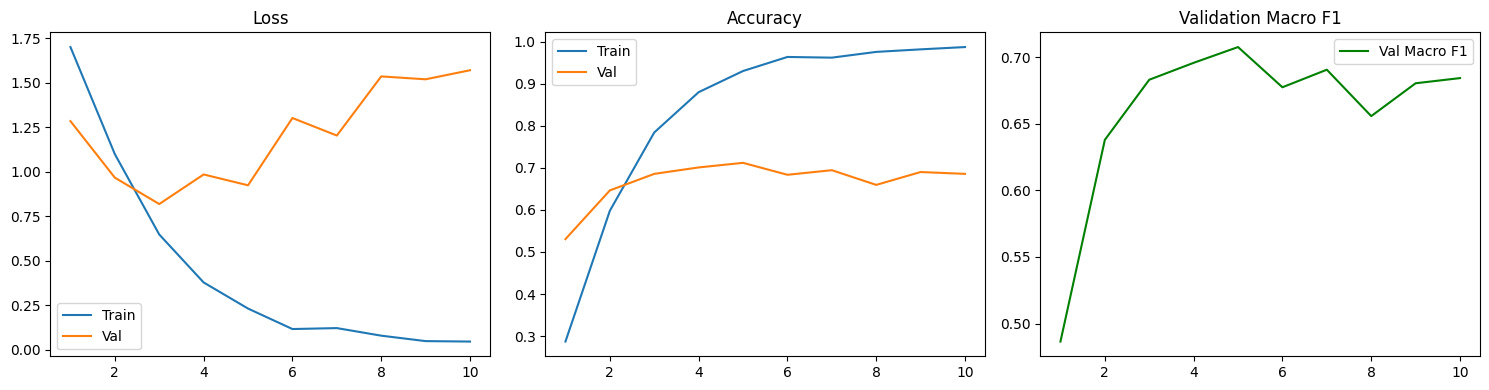

In [18]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history["train_loss"], label="Train"); axes[0].plot(epochs, history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train"); axes[1].plot(epochs, history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(epochs, history["val_f1"], label="Val Macro F1", color="green")
axes[2].set_title("Validation Macro F1"); axes[2].legend()

plt.tight_layout(); plt.show()


# STEP 18 — CLIP-Based Text-Image Alignment Model

In [19]:
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

class CLIPFakeNewsClassifier(nn.Module):
    def __init__(self, clip_model_name=CLIP_MODEL_NAME, num_classes=6, dropout=0.3):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(clip_model_name)
        clip_dim = self.clip.config.projection_dim
        self.classifier = nn.Sequential(
            nn.Linear(clip_dim * 2, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        out = self.clip(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
        fused = torch.cat([out.text_embeds, out.image_embeds], dim=1)
        return self.classifier(fused)

clip_model = CLIPFakeNewsClassifier().to(device)
print("CLIP model ready.")


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP model ready.


# STEP 19 — CLIP Dataset & DataLoaders

In [20]:
class FakedditCLIPDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {"text": str(row["clean_title"]),
                "image": Image.open(row["local_image_path"]).convert("RGB"),
                "label": int(row["6_way_label"]), "id": row["id"]}

def clip_collate_fn(batch):
    enc = clip_processor(text=[b["text"] for b in batch],
                         images=[b["image"] for b in batch],
                         return_tensors="pt", padding=True, truncation=True)
    enc["labels"] = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    enc["ids"] = [b["id"] for b in batch]
    return enc

CLIP_BATCH = 8
train_clip_loader = DataLoader(FakedditCLIPDataset(train_df_main), batch_size=CLIP_BATCH, shuffle=True,  num_workers=0, collate_fn=clip_collate_fn)
val_clip_loader   = DataLoader(FakedditCLIPDataset(val_df_main),   batch_size=CLIP_BATCH, shuffle=False, num_workers=0, collate_fn=clip_collate_fn)
print("CLIP loaders:", len(train_clip_loader), "train |", len(val_clip_loader), "val")


CLIP loaders: 229 train | 58 val


# STEP 20 — Train CLIP Model

In [21]:
clip_criterion  = nn.CrossEntropyLoss(weight=class_weights_tensor)
clip_optimizer  = AdamW(clip_model.parameters(), lr=1e-5)
NUM_CLIP_EPOCHS = 10
best_clip_f1    = -1.0
best_clip_path  = CKPT_DIR / "best_clip_model.pt"
no_improve_clip = 0

def train_eval_clip(model, tr_loader, vl_loader, criterion, optimizer, n_epochs, patience=5):
    global best_clip_f1, no_improve_clip
    for ep in range(n_epochs):
        model.train()
        for batch in tqdm(tr_loader, desc=f"CLIP Epoch {ep+1}", leave=False):
            ids = batch["input_ids"].to(device); mask = batch["attention_mask"].to(device)
            pv  = batch["pixel_values"].to(device); lbl = batch["labels"].to(device)
            optimizer.zero_grad()
            loss = criterion(model(ids, mask, pv), lbl)
            loss.backward(); optimizer.step()

        model.eval(); preds_all, labels_all = [], []
        with torch.no_grad():
            for batch in vl_loader:
                ids = batch["input_ids"].to(device); mask = batch["attention_mask"].to(device)
                pv  = batch["pixel_values"].to(device); lbl = batch["labels"]
                out = model(ids, mask, pv).argmax(1).cpu().numpy()
                preds_all.extend(out); labels_all.extend(lbl.numpy())

        vf1 = f1_score(labels_all, preds_all, average="macro")
        vacc= accuracy_score(labels_all, preds_all)
        print(f"  CLIP Ep {ep+1} → Acc: {vacc:.4f}  F1: {vf1:.4f}")

        if vf1 > best_clip_f1:
            best_clip_f1 = vf1
            torch.save(model.state_dict(), best_clip_path)
            no_improve_clip = 0; print("    ✅ Saved")
        else:
            no_improve_clip += 1
            if no_improve_clip >= patience:
                print("    ⛔ Early stop"); break

    return labels_all, preds_all

y_true_clip, y_pred_clip = train_eval_clip(
    clip_model, train_clip_loader, val_clip_loader,
    clip_criterion, clip_optimizer, NUM_CLIP_EPOCHS
)
print("\nCLIP Best Val F1:", round(best_clip_f1, 4))
print(classification_report(y_true_clip, y_pred_clip, target_names=target_names, digits=4))


CLIP Epoch 1:   0%|          | 0/229 [00:00<?, ?it/s]

  CLIP Ep 1 → Acc: 0.5393  F1: 0.5164
    ✅ Saved


CLIP Epoch 2:   0%|          | 0/229 [00:00<?, ?it/s]

  CLIP Ep 2 → Acc: 0.6135  F1: 0.6042
    ✅ Saved


CLIP Epoch 3:   0%|          | 0/229 [00:00<?, ?it/s]

...

  CLIP Ep 8 → Acc: 0.6070  F1: 0.5976


CLIP Epoch 9:   0%|          | 0/229 [00:00<?, ?it/s]

  CLIP Ep 9 → Acc: 0.6638  F1: 0.6625
    ✅ Saved


CLIP Epoch 10:   0%|          | 0/229 [00:00<?, ?it/s]

  CLIP Ep 10 → Acc: 0.6528  F1: 0.6511

CLIP Best Val F1: 0.6625
                  precision    recall  f1-score   support

            TRUE     0.5781    0.5068    0.5401        73
          SATIRE     0.6026    0.6267    0.6144        75
FALSE_CONNECTION     0.6933    0.6933    0.6933        75
        IMPOSTER     0.5294    0.5844    0.5556        77
     MANIPULATED     0.7033    0.8101    0.7529        79
      MISLEADING     0.8308    0.6835    0.7500        79

        accuracy                         0.6528       458
       macro avg     0.6563    0.6508    0.6511       458
    weighted avg     0.6580    0.6528    0.6529       458



# STEP 21 — OCR Text Extraction & Similarity

In [22]:
import easyocr, re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
sim_model  = SentenceTransformer("all-MiniLM-L6-v2")
print("OCR reader and similarity model ready.")

def extract_ocr_text(image_path, reader):
    try:
        results = reader.readtext(str(image_path), detail=0, paragraph=True)
        return " ".join([str(x) for x in results]).strip() if isinstance(results, list) else str(results)
    except Exception as e:
        return ""

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def compute_ocr_similarity(title, ocr_text):
    t, o = clean_text(title), clean_text(ocr_text)
    if len(o) < 3: return 0.0
    emb = sim_model.encode([t, o])
    return float(cosine_similarity([emb[0]], [emb[1]])[0][0])

def add_ocr_features(df):
    df = df.copy().reset_index(drop=True)
    ocr_texts, ocr_sims = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="OCR"):
        ocr = extract_ocr_text(row["local_image_path"], ocr_reader)
        sim = compute_ocr_similarity(row["clean_title"], ocr)
        ocr_texts.append(ocr); ocr_sims.append(sim)
    df["ocr_text"] = ocr_texts; df["ocr_similarity"] = ocr_sims
    return df

train_df_main = add_ocr_features(train_df_main)
val_df_main   = add_ocr_features(val_df_main)
print("OCR done. Sample:")
print(train_df_main[["clean_title","ocr_text","ocr_similarity"]].head(3).to_string())


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

OCR reader and similarity model ready.


OCR:   0%|          | 0/1828 [00:00<?, ?it/s]

OCR:   0%|          | 0/458 [00:00<?, ?it/s]

OCR done. Sample:
                                                        clean_title                                                   ocr_text  ocr_similarity
0                      to arms turkish mobilization posterworld war                                               SiLAH BASINA        0.153587
1  i spilt my drink and the splash looks like a bottle of champagne                                                                   0.000000
2                                                       lucha libre  Ski 2541 FFRFFO CUleTov FERRERO TEACMER"? 99 man bun 9.99        0.070149


# STEP 22 — Image Metadata Feature Extraction

In [23]:
import os
from PIL import ImageStat, ImageFilter

FEATURE_COLS = ["img_width","img_height","aspect_ratio","file_size",
                "mean_r","mean_g","mean_b","std_r","std_g","std_b",
                "gray_mean","gray_std","edge_mean","edge_std",
                "ocr_text_len","ocr_similarity"]

def extract_image_features(image_path):
    try:
        img  = Image.open(image_path).convert("RGB")
        gray = img.convert("L")
        w, h = img.size
        fs   = os.path.getsize(image_path)
        sr   = ImageStat.Stat(img); sg = ImageStat.Stat(gray)
        ed   = ImageStat.Stat(gray.filter(ImageFilter.FIND_EDGES))
        return {"img_width":float(w),"img_height":float(h),"aspect_ratio":w/h if h else 0.0,
                "file_size":float(fs),"mean_r":sr.mean[0],"mean_g":sr.mean[1],"mean_b":sr.mean[2],
                "std_r":sr.stddev[0],"std_g":sr.stddev[1],"std_b":sr.stddev[2],
                "gray_mean":sg.mean[0],"gray_std":sg.stddev[0],
                "edge_mean":ed.mean[0],"edge_std":ed.stddev[0]}
    except:
        return {k:0.0 for k in FEATURE_COLS[:14]}

def add_metadata_features(df):
    df = df.copy().reset_index(drop=True)
    feats = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Metadata"):
        f = extract_image_features(row["local_image_path"])
        f["ocr_text_len"]  = float(len(str(row.get("ocr_text","")).strip()))
        f["ocr_similarity"] = float(row.get("ocr_similarity", 0.0))
        feats.append(f)
    feat_df = pd.DataFrame(feats)
    return pd.concat([df, feat_df], axis=1).loc[:,~pd.concat([df,feat_df],axis=1).columns.duplicated()]

train_feat_df = add_metadata_features(train_df_main)
val_feat_df   = add_metadata_features(val_df_main)

X_train = train_feat_df[FEATURE_COLS].values; y_train = train_feat_df["6_way_label"].values
X_val   = val_feat_df[FEATURE_COLS].values;   y_val   = val_feat_df["6_way_label"].values
print("X_train:", X_train.shape, "| X_val:", X_val.shape)


Metadata:   0%|          | 0/1828 [00:00<?, ?it/s]

Metadata:   0%|          | 0/458 [00:00<?, ?it/s]

X_train: (1828, 16) | X_val: (458, 16)


# STEP 23 — XGBoost Metadata Model (Upgrade from RandomForest)

In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ✅ UPGRADE: XGBoost (was RandomForest)
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)

xgb_acc = accuracy_score(y_val, xgb_preds)
xgb_f1  = f1_score(y_val, xgb_preds, average="macro")
print(f"XGBoost  Accuracy: {xgb_acc:.4f}  |  Macro F1: {xgb_f1:.4f}")
print(classification_report(y_val, xgb_preds, target_names=target_names, digits=4))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:48:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost  Accuracy: 0.5611  |  Macro F1: 0.5565
                  precision    recall  f1-score   support

            TRUE     0.3165    0.3425    0.3289        73
          SATIRE     0.6750    0.7200    0.6968        75
FALSE_CONNECTION     0.3377    0.3467    0.3421        75
        IMPOSTER     0.3382    0.2987    0.3172        77
     MANIPULATED     1.0000    0.9747    0.9872        79
      MISLEADING     0.6753    0.6582    0.6667        79

        accuracy                         0.5611       458
       macro avg     0.5571    0.5568    0.5565       458
    weighted avg     0.5621    0.5611    0.5612       458



# STEP 24 — Learned MLP Fusion (Upgrade from fixed alpha)

In [25]:
import torch.nn.functional as F

# Get CLIP probability matrices
def get_clip_probs(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device); mask = batch["attention_mask"].to(device)
            pv  = batch["pixel_values"].to(device)
            logits = model(ids, mask, pv)
            all_probs.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(all_probs)

# Reload best CLIP model for probability extraction
best_clip_model = CLIPFakeNewsClassifier().to(device)
best_clip_model.load_state_dict(torch.load(best_clip_path, map_location=device))

clip_train_probs = get_clip_probs(best_clip_model, train_clip_loader, device)
clip_val_probs   = get_clip_probs(best_clip_model, val_clip_loader,   device)

xgb_train_probs  = xgb_model.predict_proba(X_train)
xgb_val_probs    = xgb_model.predict_proba(X_val)

print("CLIP train probs:", clip_train_probs.shape)
print("XGB  train probs:", xgb_train_probs.shape)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP train probs: (1828, 6)
XGB  train probs: (1828, 6)


In [26]:
# ✅ UPGRADE: Learned MLP fusion layer
class LearnedFusion(nn.Module):
    def __init__(self, n_classes=6):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_classes * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )
    def forward(self, x): return self.fc(x)

fusion_model = LearnedFusion(n_classes=6).to(device)
fusion_optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-3)
fusion_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Build fusion train tensors
Xf_train = torch.tensor(np.hstack([clip_train_probs, xgb_train_probs]), dtype=torch.float32)
yf_train = torch.tensor(y_train, dtype=torch.long)
Xf_val   = torch.tensor(np.hstack([clip_val_probs,   xgb_val_probs]),   dtype=torch.float32)
yf_val   = torch.tensor(y_val, dtype=torch.long)

fusion_ds_train = torch.utils.data.TensorDataset(Xf_train, yf_train)
fusion_loader   = torch.utils.data.DataLoader(fusion_ds_train, batch_size=32, shuffle=True)

best_fusion_f1  = -1.0
best_fusion_path= CKPT_DIR / "best_fusion_mlp.pt"

for ep in range(50):
    fusion_model.train()
    for xb, yb in fusion_loader:
        xb = xb.to(device); yb = yb.to(device)
        fusion_optimizer.zero_grad()
        loss = fusion_criterion(fusion_model(xb), yb)
        loss.backward(); fusion_optimizer.step()

    fusion_model.eval()
    with torch.no_grad():
        preds = fusion_model(Xf_val.to(device)).argmax(1).cpu().numpy()
    fv = f1_score(y_val, preds, average="macro")
    if fv > best_fusion_f1:
        best_fusion_f1 = fv
        torch.save(fusion_model.state_dict(), best_fusion_path)

print(f"\nBest Learned Fusion F1: {best_fusion_f1:.4f}")
fusion_model.load_state_dict(torch.load(best_fusion_path, map_location=device))
with torch.no_grad():
    fusion_preds = fusion_model(Xf_val.to(device)).argmax(1).cpu().numpy()

print(f"Learned Fusion Accuracy: {accuracy_score(y_val, fusion_preds):.4f}")
print(classification_report(y_val, fusion_preds, target_names=target_names, digits=4))



Best Learned Fusion F1: 0.5572
Learned Fusion Accuracy: 0.5611
                  precision    recall  f1-score   support

            TRUE     0.3059    0.3562    0.3291        73
          SATIRE     0.6750    0.7200    0.6968        75
FALSE_CONNECTION     0.3514    0.3467    0.3490        75
        IMPOSTER     0.3284    0.2857    0.3056        77
     MANIPULATED     1.0000    0.9747    0.9872        79
      MISLEADING     0.6933    0.6582    0.6753        79

        accuracy                         0.5611       458
       macro avg     0.5590    0.5569    0.5572       458
    weighted avg     0.5641    0.5611    0.5618       458



# STEP 25 — Full Model Comparison

Validation:   0%|          | 0/29 [00:00<?, ?it/s]

                                 Model  Accuracy  Macro F1
RoBERTa + ResNet50 (baseline-improved)    0.7118    0.7077
                         CLIP ViT-B/32    0.6528    0.6625
                      XGBoost Metadata    0.5611    0.5565
                    Learned MLP Fusion    0.5611    0.5572


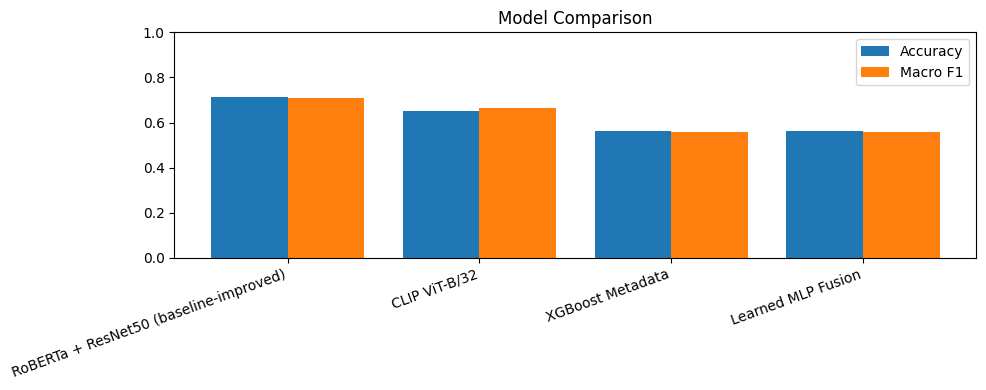

In [27]:
_, baseline_acc, baseline_f1, _, _ = evaluate_model(best_model, val_loader, criterion, device)

results_table = pd.DataFrame([
    ["RoBERTa + ResNet50 (baseline-improved)", round(baseline_acc,4), round(baseline_f1,4)],
    ["CLIP ViT-B/32",                          round(accuracy_score(y_true_clip, y_pred_clip),4), round(best_clip_f1,4)],
    ["XGBoost Metadata",                       round(xgb_acc,4), round(xgb_f1,4)],
    ["Learned MLP Fusion",                     round(accuracy_score(y_val, fusion_preds),4), round(best_fusion_f1,4)],
], columns=["Model", "Accuracy", "Macro F1"])

print(results_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,4))
x = range(len(results_table))
ax.bar([i-0.2 for i in x], results_table["Accuracy"], 0.4, label="Accuracy")
ax.bar([i+0.2 for i in x], results_table["Macro F1"], 0.4, label="Macro F1")
ax.set_xticks(list(x)); ax.set_xticklabels(results_table["Model"], rotation=20, ha="right")
ax.set_ylim(0, 1); ax.legend(); ax.set_title("Model Comparison")
plt.tight_layout(); plt.show()


# STEP 26 — Consistency Score Computation (Core Novelty 🔥)

In [28]:
def compute_consistency_score(clip_probs, ocr_similarity, metadata_probs):
    text_image_alignment = float(np.max(clip_probs))
    metadata_score       = float(np.max(metadata_probs))
    consistency_score    = (0.5 * text_image_alignment +
                            0.3 * float(ocr_similarity) +
                            0.2 * metadata_score)
    return {"consistency_score": consistency_score,
            "text_image_alignment": text_image_alignment,
            "metadata_score": metadata_score}

print("Consistency score function ready.")


Consistency score function ready.


# STEP 27 — Full Prediction + Explanation + Verification Pipeline

In [29]:
label_map = {0:"TRUE",1:"SATIRE",2:"FALSE_CONNECTION",
             3:"IMPOSTER",4:"MANIPULATED",5:"MISLEADING"}

def predict_with_consistency_reasoning(
    title, image_path, clip_model, clip_processor, xgb_model,
    fusion_model, ocr_reader, consistency_threshold=0.2
):
    # OCR
    ocr_text = extract_ocr_text(image_path, ocr_reader)
    ocr_sim  = compute_ocr_similarity(title, ocr_text)

    # CLIP probs
    image = Image.open(image_path).convert("RGB")
    enc = clip_processor(text=[title], images=[image],
                         return_tensors="pt", padding=True, truncation=True)
    clip_model.eval()
    with torch.no_grad():
        logits = clip_model(enc["input_ids"].to(device),
                            enc["attention_mask"].to(device),
                            enc["pixel_values"].to(device))
        clip_p = F.softmax(logits, dim=1).cpu().numpy()[0]

    # XGBoost probs
    img_feat = extract_image_features(image_path)
    img_feat["ocr_text_len"]   = float(len(clean_text(ocr_text)))
    img_feat["ocr_similarity"] = float(ocr_sim)
    feat_vec = np.array([img_feat[c] for c in FEATURE_COLS], dtype=np.float32).reshape(1,-1)
    xgb_p = xgb_model.predict_proba(feat_vec)[0]

    # Learned fusion
    fusion_input = torch.tensor(np.hstack([clip_p, xgb_p]), dtype=torch.float32).unsqueeze(0).to(device)
    fusion_model.eval()
    with torch.no_grad():
        final_p = F.softmax(fusion_model(fusion_input), dim=1).cpu().numpy()[0]

    pred_idx   = int(np.argmax(final_p))
    cons_info  = compute_consistency_score(clip_p, ocr_sim, xgb_p)
    status     = "CONSISTENT" if cons_info["consistency_score"] >= consistency_threshold else "INCONSISTENT"

    return {
        "predicted_label": label_map[pred_idx],
        "confidence":       float(final_p[pred_idx]),
        "ocr_text":         ocr_text,
        "ocr_similarity":   float(ocr_sim),
        "consistency_score":float(cons_info["consistency_score"]),
        "status":           status,
        "explanation": {
            "text_image_alignment": float(cons_info["text_image_alignment"]),
            "ocr_text_alignment":   float(ocr_sim),
            "metadata_signal":      float(cons_info["metadata_score"])
        }
    }

print("Full reasoning pipeline ready.")


Full reasoning pipeline ready.


# STEP 28 — Consistency Analysis on Validation Set

In [30]:
reasoning_outputs = []

for _, row in tqdm(val_feat_df.iterrows(), total=len(val_feat_df)):
    pred = predict_with_consistency_reasoning(
        title=row["clean_title"], image_path=row["local_image_path"],
        clip_model=best_clip_model, clip_processor=clip_processor,
        xgb_model=xgb_model, fusion_model=fusion_model,
        ocr_reader=ocr_reader, consistency_threshold=0.2
    )
    reasoning_outputs.append({
        "id":               row["id"],
        "clean_title":      row["clean_title"],
        "true_label":       label_map[int(row["6_way_label"])],
        "pred_label":       pred["predicted_label"],
        "confidence":       pred["confidence"],
        "ocr_similarity":   pred["ocr_similarity"],
        "consistency_score":pred["consistency_score"],
        "status":           pred["status"],
        "text_image_alignment": pred["explanation"]["text_image_alignment"],
        "metadata_signal":      pred["explanation"]["metadata_signal"],
        "correct": pred["predicted_label"] == label_map[int(row["6_way_label"])]
    })

reasoning_df = pd.DataFrame(reasoning_outputs)
print("Reasoning done. Shape:", reasoning_df.shape)
print("\nOverall accuracy from reasoning pipeline:", round(reasoning_df["correct"].mean(), 4))


  0%|          | 0/458 [00:00<?, ?it/s]

Reasoning done. Shape: (458, 11)

Overall accuracy from reasoning pipeline: 0.5611


# STEP 29 — Consistency Visualizations

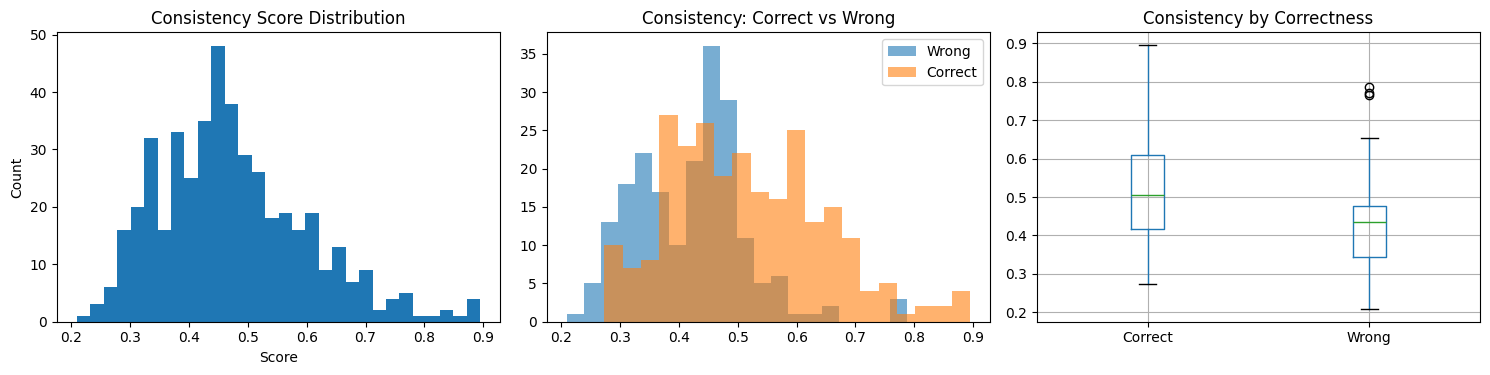

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram: consistency score distribution
axes[0].hist(reasoning_df["consistency_score"], bins=30)
axes[0].set_title("Consistency Score Distribution")
axes[0].set_xlabel("Score"); axes[0].set_ylabel("Count")

# Histogram: correct vs wrong
for label, grp in reasoning_df.groupby("correct"):
    axes[1].hist(grp["consistency_score"], bins=20, alpha=0.6,
                 label="Correct" if label else "Wrong")
axes[1].set_title("Consistency: Correct vs Wrong")
axes[1].legend()

# Boxplot
reasoning_df["Result"] = reasoning_df["correct"].map({True:"Correct", False:"Wrong"})
reasoning_df.boxplot(column="consistency_score", by="Result", ax=axes[2])
axes[2].set_title("Consistency by Correctness"); axes[2].set_xlabel("")
plt.suptitle(""); plt.tight_layout(); plt.show()


# STEP 30 — Consistency Threshold Analysis

 threshold  num_consistent  accuracy
      0.10             458  0.561135
      0.15             458  0.561135
      0.20             458  0.561135
      0.25             454  0.566079
      0.30             433  0.581986
      0.35             379  0.617414
      0.40             320  0.631250
      0.45             251  0.661355
      0.50             163  0.822086
      0.55             113  0.884956
      0.60              77  0.909091
      0.65              45  0.911111
      0.70              24  0.875000
      0.75              14  0.785714
      0.80               8  1.000000
      0.85               5  1.000000


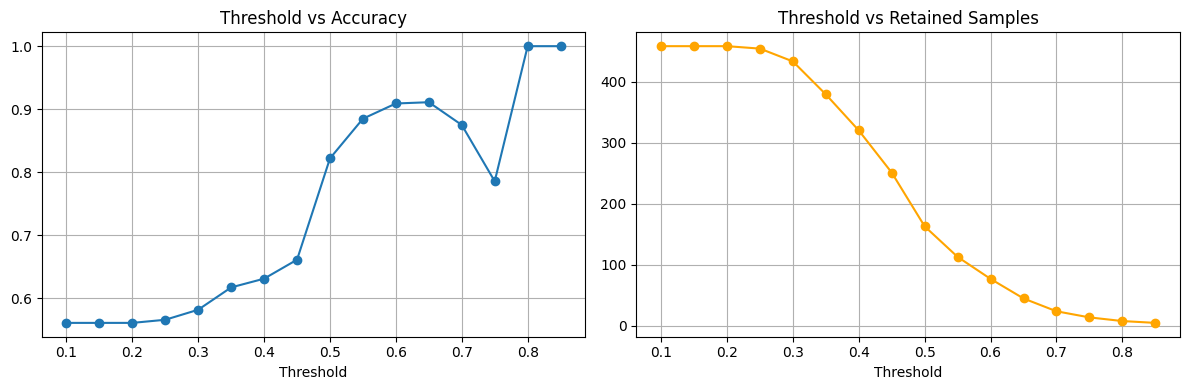

In [32]:
threshold_results = []
for thr in np.arange(0.1, 0.91, 0.05):
    consistent = reasoning_df[reasoning_df["consistency_score"] >= thr]
    if len(consistent) == 0: continue
    threshold_results.append({
        "threshold": round(float(thr), 2),
        "num_consistent": int(len(consistent)),
        "accuracy":       float(consistent["correct"].mean())
    })

thr_df = pd.DataFrame(threshold_results)
print(thr_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thr_df["threshold"], thr_df["accuracy"], marker="o")
axes[0].set_title("Threshold vs Accuracy"); axes[0].set_xlabel("Threshold"); axes[0].grid(True)
axes[1].plot(thr_df["threshold"], thr_df["num_consistent"], marker="o", color="orange")
axes[1].set_title("Threshold vs Retained Samples"); axes[1].set_xlabel("Threshold"); axes[1].grid(True)
plt.tight_layout(); plt.show()


# STEP 31 — Ablation Study

In [33]:
ablation_table = pd.DataFrame([
    {"Setting":"Without OCR",      "Model":"CLIP only",
     "Val Accuracy": round(accuracy_score(y_true_clip, y_pred_clip),4),
     "Val Macro F1": round(best_clip_f1,4)},
    {"Setting":"Without Metadata", "Model":"CLIP + OCR",
     "Val Accuracy": None, "Val Macro F1": None},       # fill if you run CLIP+OCR variant
    {"Setting":"Full Fusion",      "Model":"CLIP + XGBoost + Learned MLP",
     "Val Accuracy": round(accuracy_score(y_val, fusion_preds),4),
     "Val Macro F1": round(best_fusion_f1,4)},
])
print(ablation_table.to_string(index=False))


         Setting                        Model  Val Accuracy  Val Macro F1
     Without OCR                    CLIP only        0.6528        0.6625
Without Metadata                   CLIP + OCR           NaN           NaN
     Full Fusion CLIP + XGBoost + Learned MLP        0.5611        0.5572


# STEP 32 — Confusion Matrices

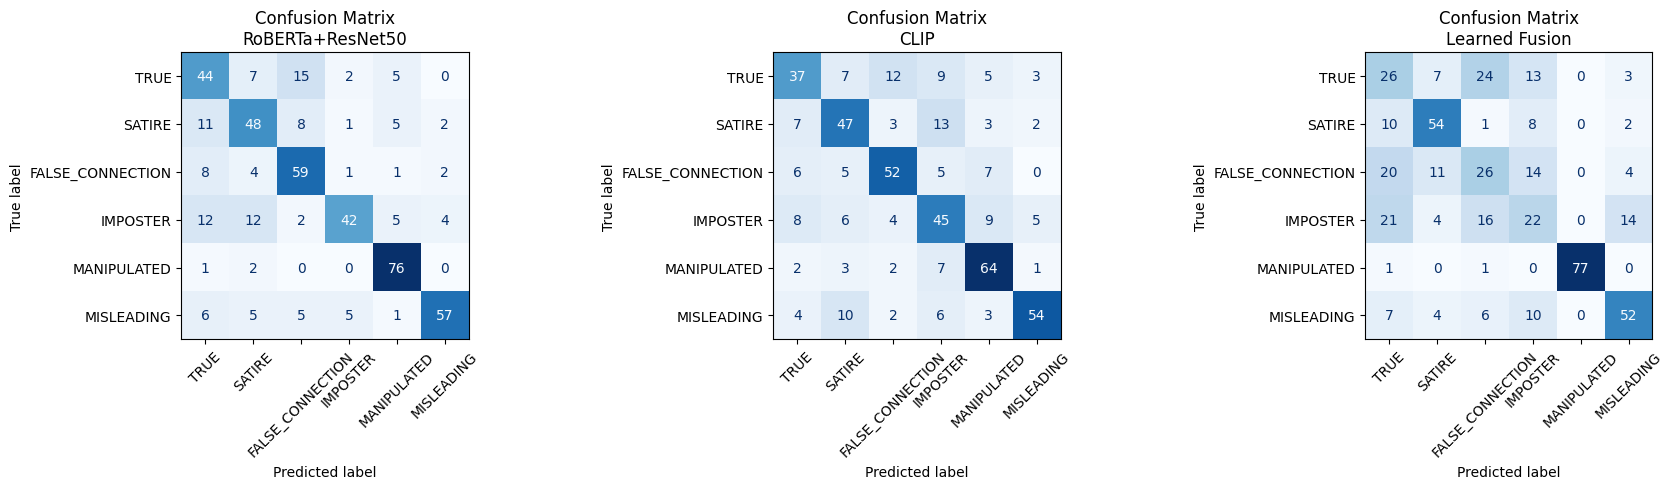

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title in zip(
    axes,
    [y_pred, y_pred_clip, fusion_preds],
    ["RoBERTa+ResNet50", "CLIP", "Learned Fusion"]
):
    ConfusionMatrixDisplay.from_predictions(
        y_val, preds,
        display_labels=[label_map[i] for i in range(6)],
        cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"Confusion Matrix\n{title}")

plt.tight_layout(); plt.show()


# STEP 33 — Save All Results

In [35]:
reasoning_df.to_csv(OUTPUT_DIR / "consistency_reasoning_results.csv", index=False)
thr_df.to_csv(OUTPUT_DIR / "threshold_analysis.csv", index=False)
results_table.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
ablation_table.to_csv(OUTPUT_DIR / "ablation_table.csv", index=False)
print("All results saved to:", OUTPUT_DIR)


All results saved to: /content/fake_news_project/outputs


# STEP 34 — Final Summary & Framework Positioning

In [36]:
framework_table = pd.DataFrame([
    ["Text-Image Alignment",    "CLIP ViT-B/32",       "Semantic cross-modal agreement"],
    ["OCR-Text Consistency",    "EasyOCR + MiniLM",    "Embedded text vs headline match"],
    ["Metadata Reasoning",      "XGBoost",             "Visual feature-based signal"],
    ["Cross-Modal Fusion",      "Learned MLP",         "Adaptive combination of modalities"],
    ["Consistency Verification","Threshold scoring",   "Flags inconsistent samples"],
], columns=["Component", "Method", "Purpose"])

print("\n🔥 Multimodal Consistency Reasoning Framework — Component Summary")
print(framework_table.to_string(index=False))

print("\n📊 Final Model Results:")
print(results_table.to_string(index=False))



🔥 Multimodal Consistency Reasoning Framework — Component Summary
               Component            Method                            Purpose
    Text-Image Alignment     CLIP ViT-B/32     Semantic cross-modal agreement
    OCR-Text Consistency  EasyOCR + MiniLM    Embedded text vs headline match
      Metadata Reasoning           XGBoost        Visual feature-based signal
      Cross-Modal Fusion       Learned MLP Adaptive combination of modalities
Consistency Verification Threshold scoring         Flags inconsistent samples

📊 Final Model Results:
                                 Model  Accuracy  Macro F1
RoBERTa + ResNet50 (baseline-improved)    0.7118    0.7077
                         CLIP ViT-B/32    0.6528    0.6625
                      XGBoost Metadata    0.5611    0.5565
                    Learned MLP Fusion    0.5611    0.5572


# Figure for paper

  Models detected: ['RoBERTa + ResNet-50', 'CLIP ViT-B/32', 'XGBoost Metadata', 'Learned MLP Fusion']
  history keys   : ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1']
  reasoning_df   : found
  threshold data : found


  Generating publication figures from your notebook results ...



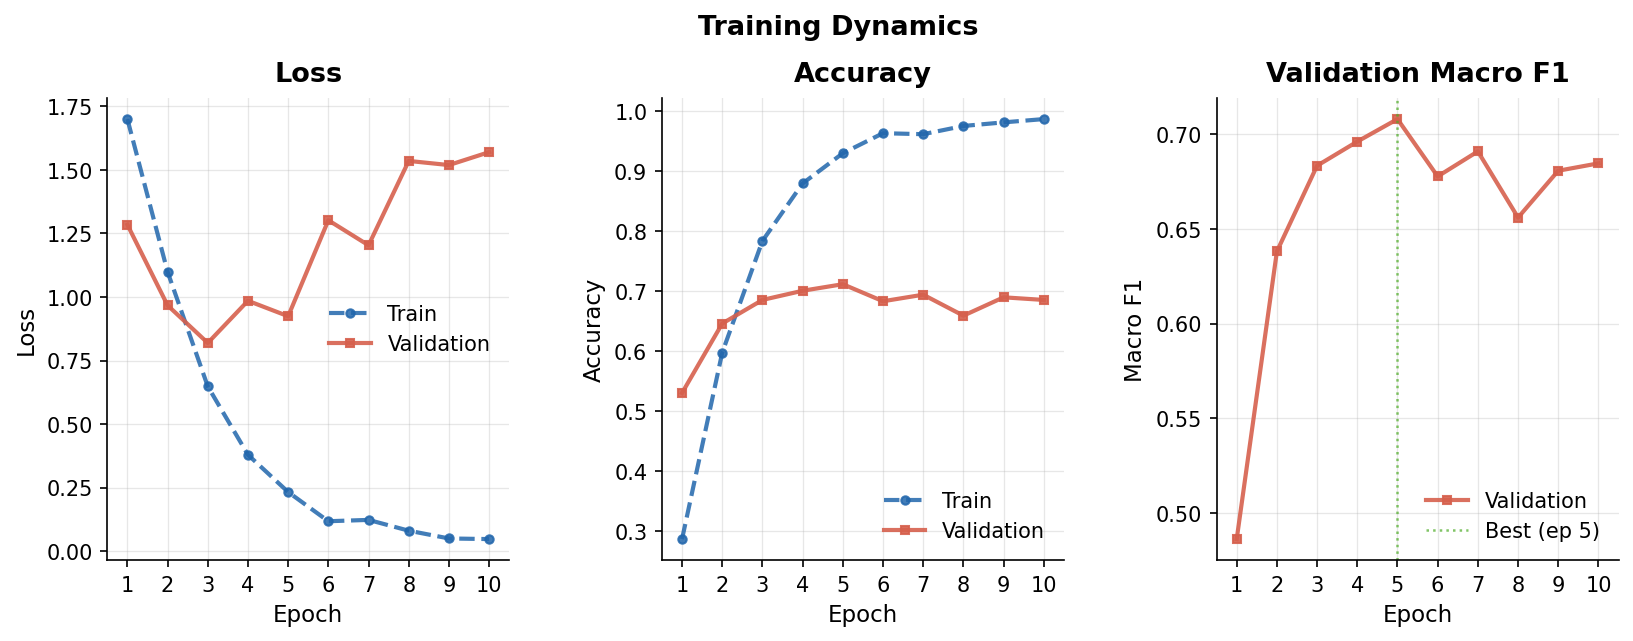

  ✅  fig1_training_curves saved  →  /content/fake_news_project/outputs/fig1_training_curves.png



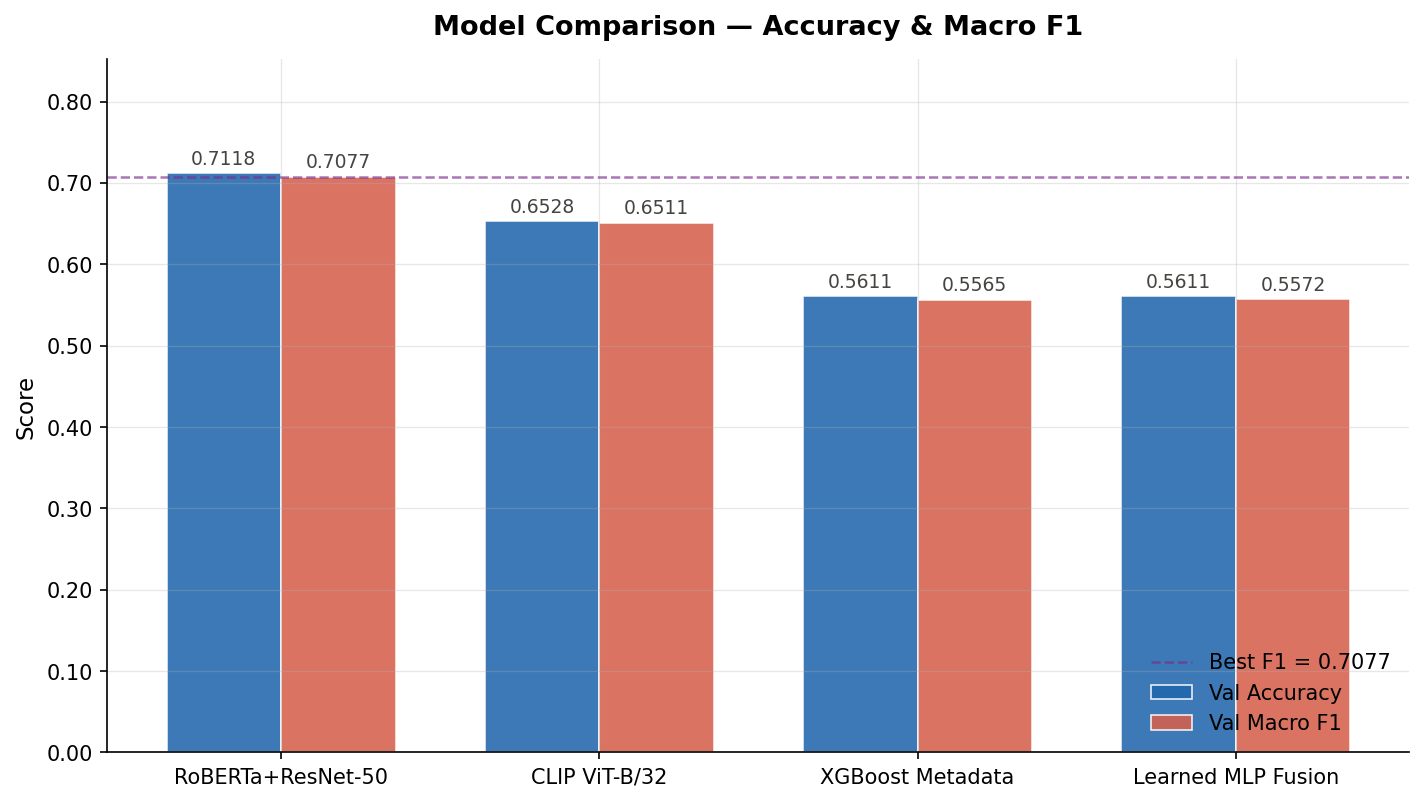

  ✅  fig2_model_comparison saved  →  /content/fake_news_project/outputs/fig2_model_comparison.png



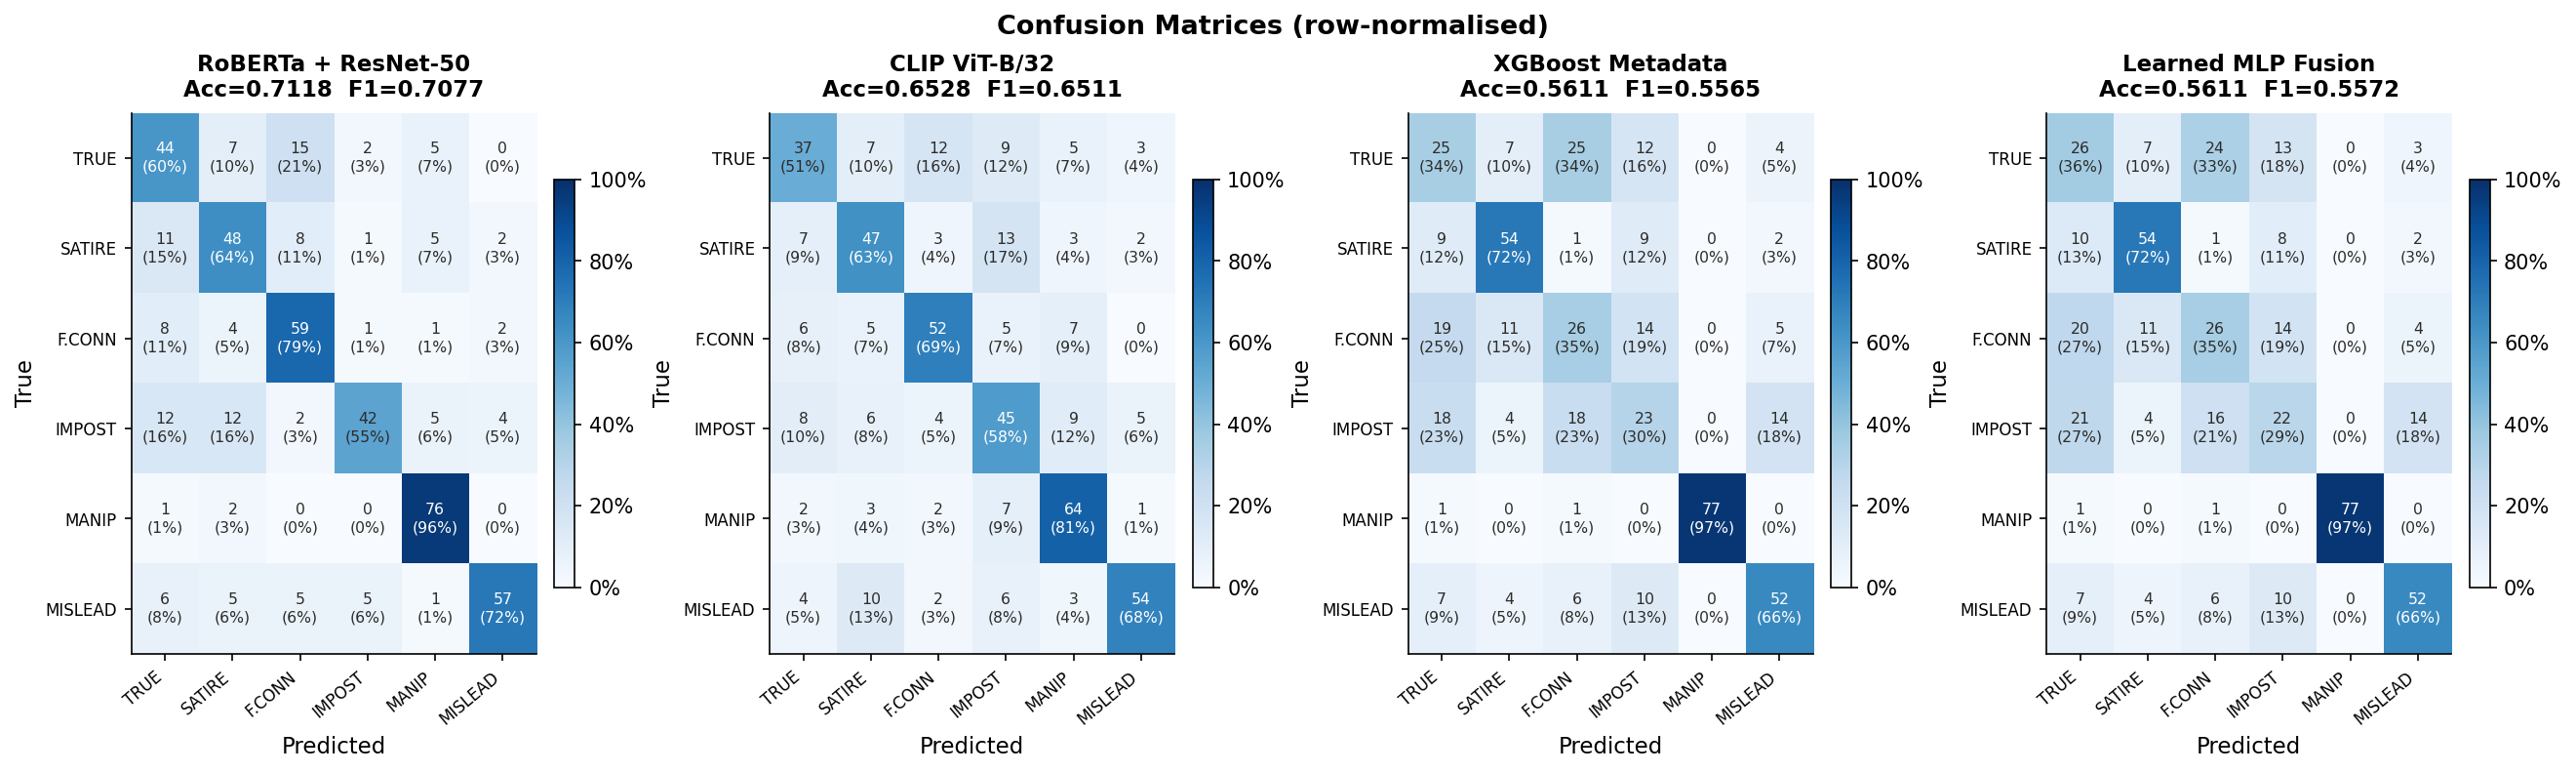

  ✅  fig3_confusion_matrices saved  →  /content/fake_news_project/outputs/fig3_confusion_matrices.png



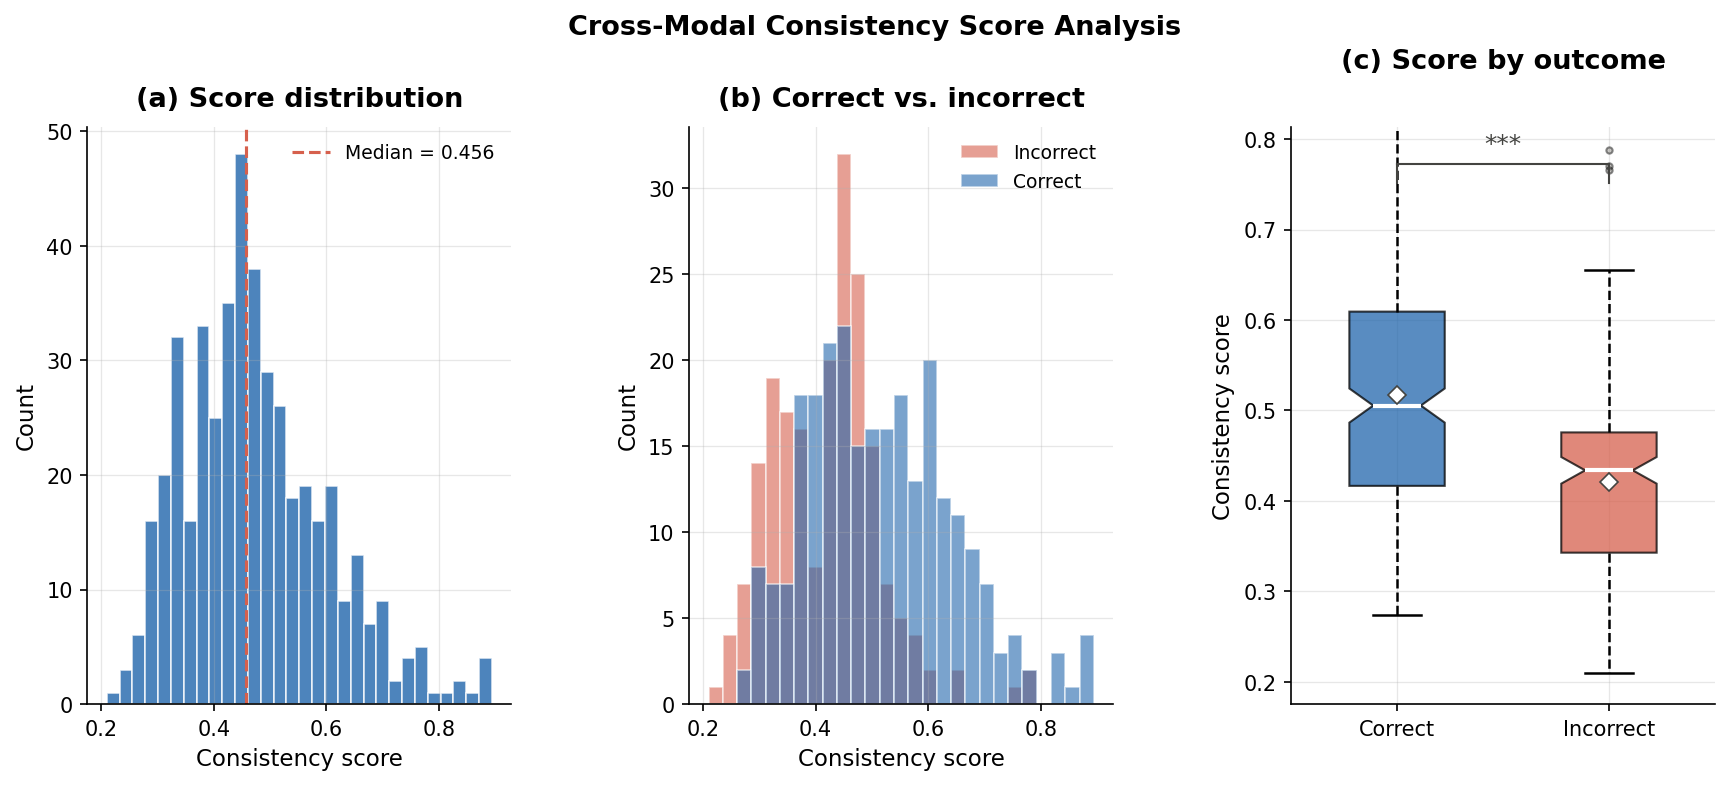

  ✅  fig4_consistency_analysis saved  →  /content/fake_news_project/outputs/fig4_consistency_analysis.png



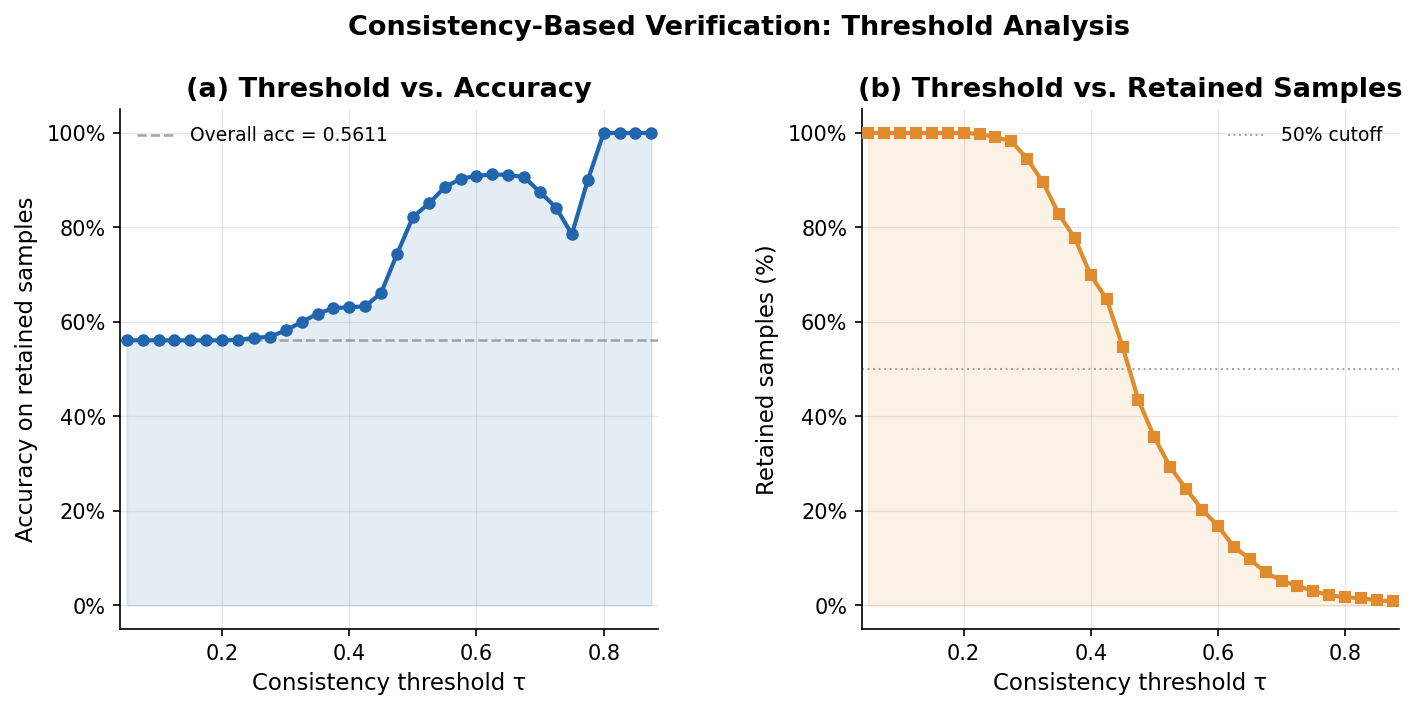

  ✅  fig5_threshold_analysis saved  →  /content/fake_news_project/outputs/fig5_threshold_analysis.png



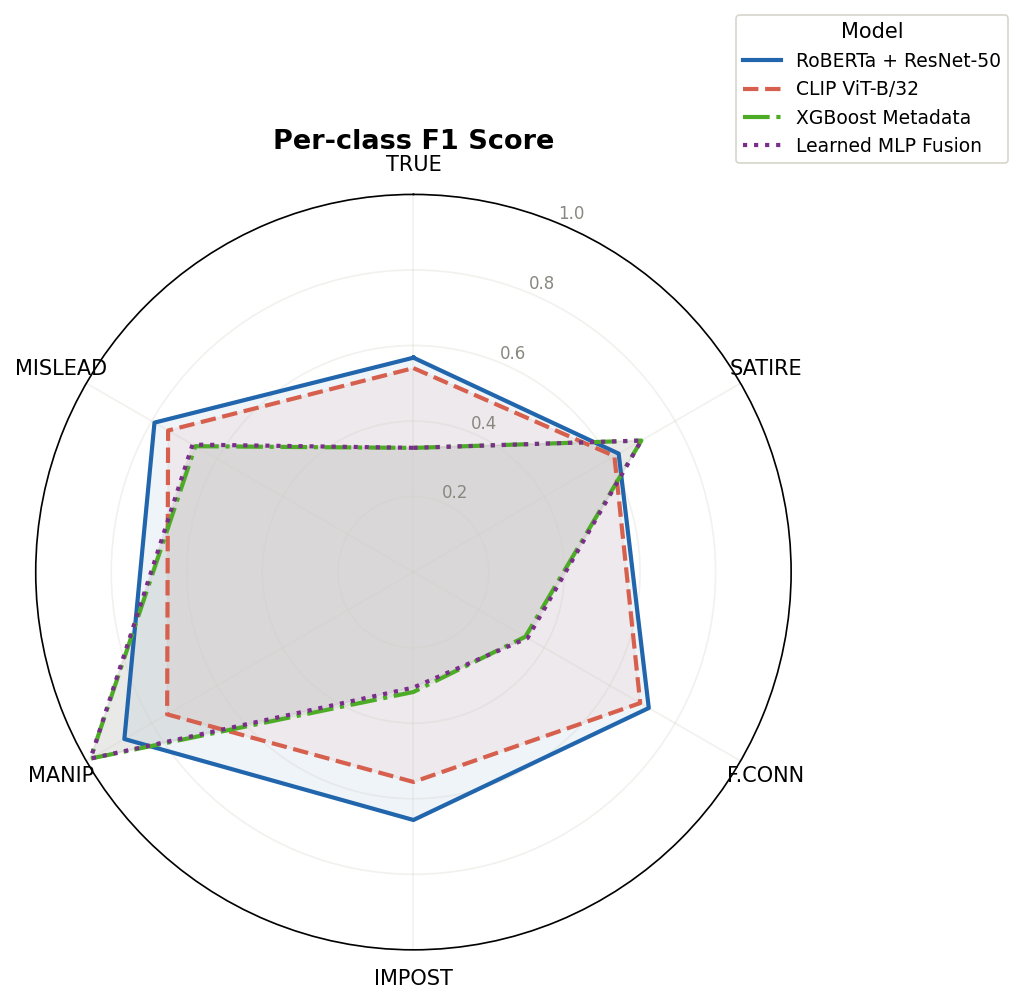

  ✅  fig6_perclass_radar saved  →  /content/fake_news_project/outputs/fig6_perclass_radar.png



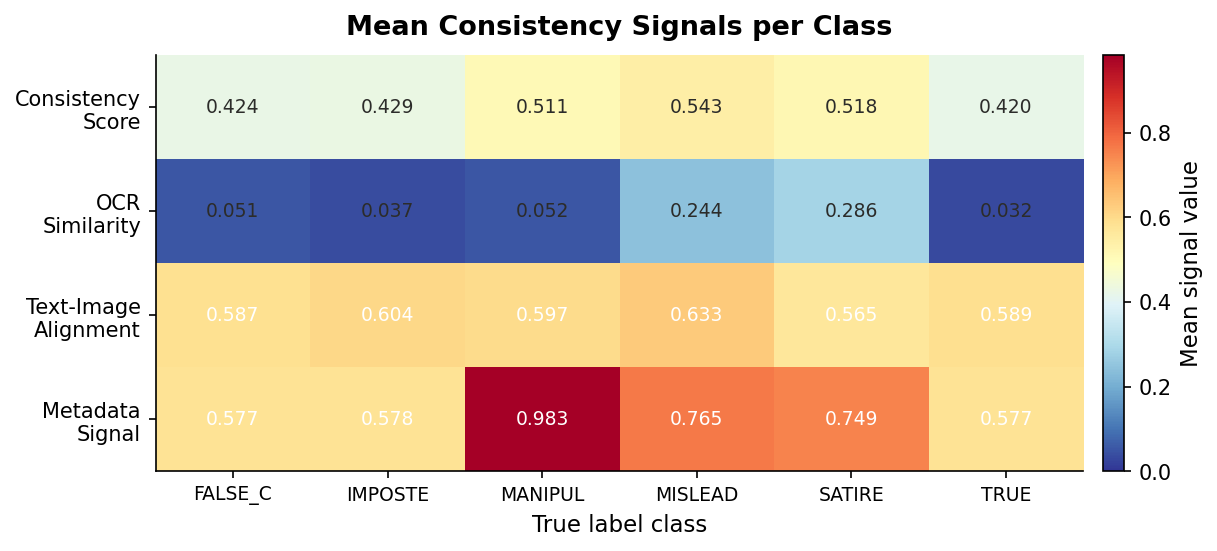

  ✅  fig7_signal_heatmap saved  →  /content/fake_news_project/outputs/fig7_signal_heatmap.png



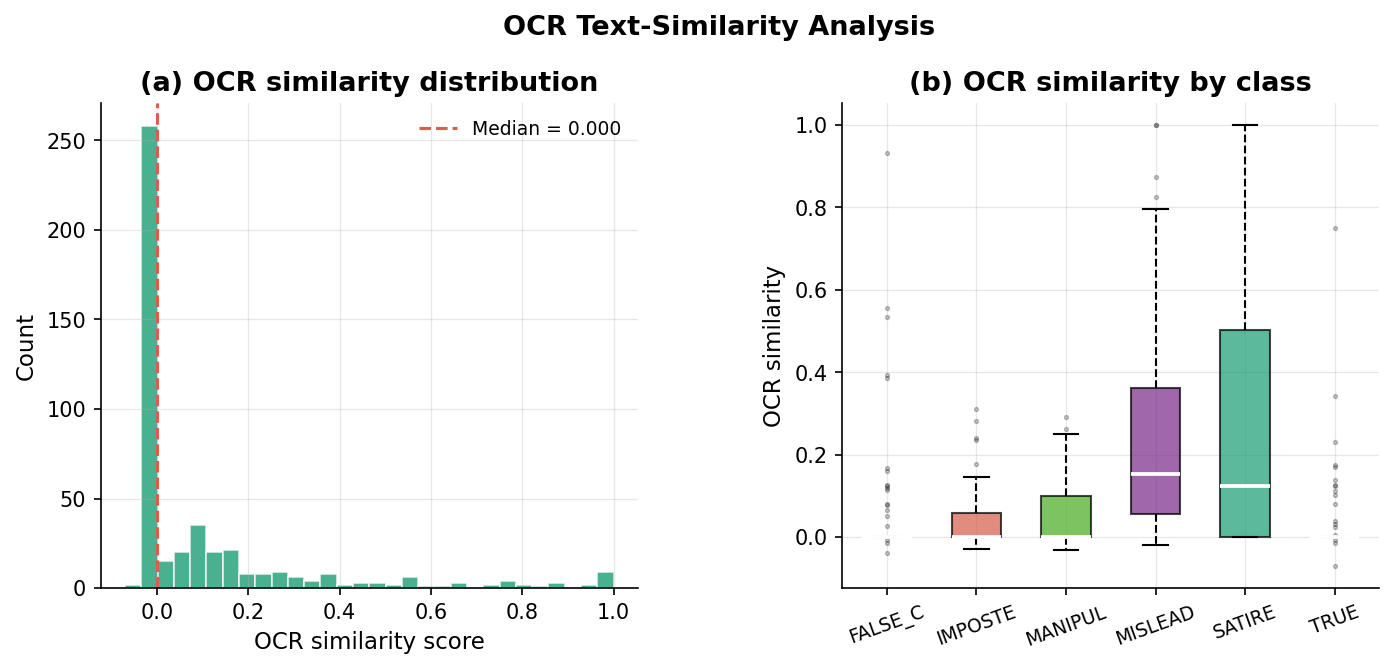

  ✅  fig8_ocr_distribution saved  →  /content/fake_news_project/outputs/fig8_ocr_distribution.png



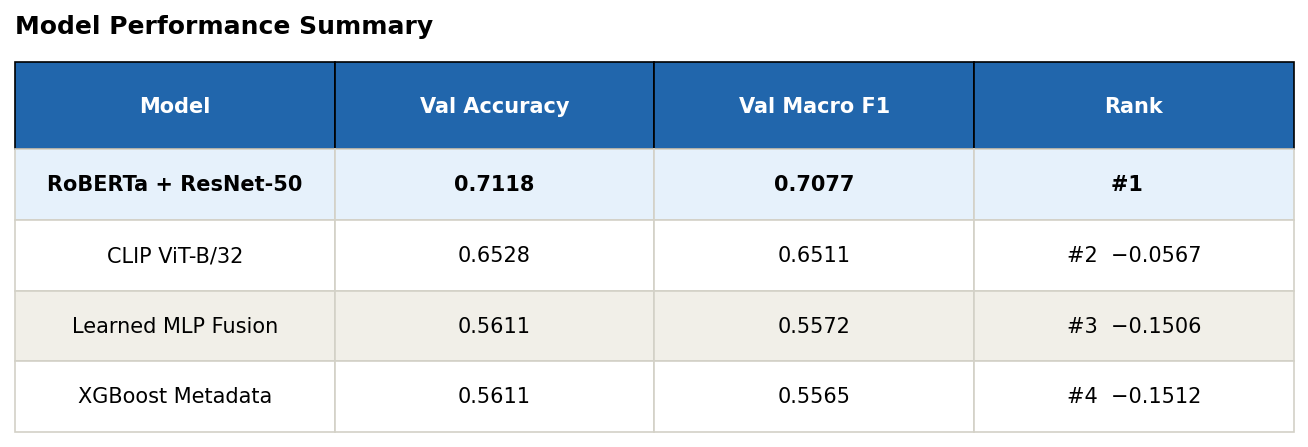

  ✅  fig9_summary_table saved  →  /content/fake_news_project/outputs/fig9_summary_table.png

  All figures saved to: /content/fake_news_project/outputs
  .pdf = vector (use in LaTeX/Word paper)
  .png = high-res raster (300 dpi)


In [39]:
"""
=============================================================================
  STEP 35 — Publication-Quality Figures  (FIXED — no overlapping)
  Drop-in replacement for the original Step 35.
  Changes vs original:
    • Fig 2  — taller figure, rotated x-labels, increased bottom margin
    • Fig 4  — title pad increased, significance text placed safely below top
    • Fig 6  — figure wider, legend anchor pushed further right, tight_layout
=============================================================================
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

try:
    from scipy import stats as _scipy_stats
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False

from sklearn.metrics import (confusion_matrix, f1_score,
                              accuracy_score, classification_report)

# ─── Publication style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.labelsize':     11,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.30,
    'grid.linewidth':     0.6,
    'lines.linewidth':    2.0,
    'patch.linewidth':    0.8,
})

C_BLUE   = '#2166ac'
C_ORANGE = '#d6604d'
C_GREEN  = '#4dac26'
C_PURPLE = '#7b2d8b'
C_TEAL   = '#1d9e75'
C_GREY   = '#888780'
C_AMBER  = '#e08c2e'

SAVE_DIR = OUTPUT_DIR   # from your notebook

# ─── Dynamically discover available model results ────────────────────────────
_g = globals()

def _resolve(name):
    return _g.get(name, None)

_model_registry = []
for _name, _yt, _yp in [
    ('RoBERTa + ResNet-50', 'y_true', 'y_pred'),
    ('CLIP ViT-B/32',       'y_true_clip', 'y_pred_clip'),
    ('XGBoost Metadata',    'y_val', 'xgb_preds'),
    ('Learned MLP Fusion',  'y_val', 'fusion_preds'),
]:
    _yt_val = _resolve(_yt)
    _yp_val = _resolve(_yp)
    if _yt_val is not None and _yp_val is not None:
        _model_registry.append({
            'name':   _name,
            'y_true': np.array(_yt_val),
            'y_pred': np.array(_yp_val),
            'acc':    accuracy_score(_yt_val, _yp_val),
            'f1':     f1_score(_yt_val, _yp_val, average='macro'),
        })

print(f'  Models detected: {[m["name"] for m in _model_registry]}')

_label_map = _resolve('label_map') or _resolve('label_names') or \
             {0:'TRUE',1:'SATIRE',2:'FALSE_CONNECTION',
              3:'IMPOSTER',4:'MANIPULATED',5:'MISLEADING'}
_short_labels = ['TRUE','SATIRE','F.CONN','IMPOST','MANIP','MISLEAD']
_num_classes  = len(_label_map)
_history      = _resolve('history') or {}
_rdf          = _resolve('reasoning_df')
_thr_df       = _resolve('thr_df')

print(f'  history keys   : {list(_history.keys())}')
print(f'  reasoning_df   : {"found" if _rdf is not None else "not found"}')
print(f'  threshold data : {"found" if _thr_df is not None else "not found"}')
print()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Training Curves  (unchanged)
# ═══════════════════════════════════════════════════════════════════════════════
def fig1_training_curves():
    if not _history or 'train_loss' not in _history:
        print('  ⚠  Fig 1 skipped: history dict not found.'); return

    epochs = list(range(1, len(_history['train_loss']) + 1))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.subplots_adjust(wspace=0.38)

    panels = [
        ('train_loss', 'val_loss', 'Loss',               'Loss'),
        ('train_acc',  'val_acc',  'Accuracy',            'Accuracy'),
        (None,         'val_f1',   'Validation Macro F1', 'Macro F1'),
    ]

    for ax, (tr_k, vl_k, title, ylabel) in zip(axes, panels):
        if tr_k and tr_k in _history:
            ax.plot(epochs, _history[tr_k], color=C_BLUE,
                    linestyle='--', marker='o', markersize=4,
                    label='Train', alpha=0.85)
        if vl_k in _history:
            ax.plot(epochs, _history[vl_k], color=C_ORANGE,
                    linestyle='-', marker='s', markersize=4,
                    label='Validation', alpha=0.90)
            if vl_k == 'val_f1':
                best_ep = int(np.argmax(_history[vl_k])) + 1
                ax.axvline(best_ep, color=C_GREEN, linewidth=1.2,
                           linestyle=':', alpha=0.7,
                           label=f'Best (ep {best_ep})')

        ax.set_title(title, fontweight='bold', pad=8)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_xlim(0.5, len(epochs) + 0.5)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(frameon=False, loc='best')

    fig.suptitle('Training Dynamics', fontsize=13, fontweight='bold', y=1.02)
    _save(fig, 'fig1_training_curves')


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Model Comparison Bar Chart
# FIX: taller figure + angled x-labels + explicit bottom margin so labels
#      never collide with the bars or each other
# ═══════════════════════════════════════════════════════════════════════════════
def fig2_model_comparison():
    if not _model_registry:
        print('  ⚠  Fig 2 skipped: no model results found.'); return

    names = [m['name']  for m in _model_registry]
    accs  = [m['acc']   for m in _model_registry]
    f1s   = [m['f1']    for m in _model_registry]
    x     = np.arange(len(names))
    w     = 0.36

    fig, ax = plt.subplots(figsize=(max(10, len(names)*2.8), 6))

    b_acc = ax.bar(x - w/2, accs, w, color=C_BLUE,   alpha=0.88,
                   label='Val Accuracy', edgecolor='white')
    b_f1  = ax.bar(x + w/2, f1s,  w, color=C_ORANGE, alpha=0.88,
                   label='Val Macro F1', edgecolor='white')

    for bar in list(b_acc) + list(b_f1):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.006,
                f'{h:.4f}', ha='center', va='bottom',
                fontsize=9, color='#444441', fontweight='500')

    best_f1 = max(f1s)
    ax.axhline(best_f1, color=C_PURPLE, linewidth=1.2,
               linestyle='--', alpha=0.65,
               label=f'Best F1 = {best_f1:.4f}')

    ax.set_xticks(x)
    # Horizontal labels — never rotated, never cropped
    clean_names = [n.replace(' + ', '+') for n in names]
    ax.set_xticklabels(clean_names, fontsize=10, rotation=0, ha='center')

    ax.set_ylim(0, min(1.0, max(accs + f1s) + 0.14))
    ax.set_ylabel('Score')
    ax.set_title('Model Comparison — Accuracy & Macro F1',
                 fontweight='bold', pad=12)
    ax.legend(frameon=False, loc='lower right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # savefig bbox='tight' in _save() handles all clipping automatically
    _save(fig, 'fig2_model_comparison')


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Confusion Matrices  (unchanged)
# ═══════════════════════════════════════════════════════════════════════════════
def fig3_confusion_matrices():
    if not _model_registry:
        print('  ⚠  Fig 3 skipped.'); return

    n = len(_model_registry)
    fig, axes = plt.subplots(1, n, figsize=(5.2*n, 4.8))
    fig.subplots_adjust(wspace=0.44)
    if n == 1:
        axes = [axes]

    for ax, m in zip(axes, _model_registry):
        cm   = confusion_matrix(m['y_true'], m['y_pred'])
        norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        im   = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')

        for i in range(_num_classes):
            for j in range(_num_classes):
                col = 'white' if norm[i,j] > 0.55 else '#2c2c2a'
                ax.text(j, i, f'{cm[i,j]}\n({norm[i,j]:.0%})',
                        ha='center', va='center',
                        fontsize=7.5, color=col, linespacing=1.3)

        ax.set_xticks(range(_num_classes))
        ax.set_xticklabels(_short_labels[:_num_classes],
                           rotation=40, ha='right', fontsize=8)
        ax.set_yticks(range(_num_classes))
        ax.set_yticklabels(_short_labels[:_num_classes], fontsize=8)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{m["name"]}\nAcc={m["acc"]:.4f}  F1={m["f1"]:.4f}',
                     fontweight='bold', pad=8, fontsize=11)
        ax.grid(False)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                     format=mticker.PercentFormatter(xmax=1, decimals=0))

    fig.suptitle('Confusion Matrices (row-normalised)',
                 fontsize=13, fontweight='bold', y=1.02)
    _save(fig, 'fig3_confusion_matrices')


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Consistency Score Analysis
# FIX: significance annotation no longer clips into the panel title.
#      We place the bracket + star text INSIDE the axes data range instead
#      of above it, and give the title extra top padding.
# ═══════════════════════════════════════════════════════════════════════════════
def fig4_consistency_analysis():
    if _rdf is None:
        print('  ⚠  Fig 4 skipped: reasoning_df not found.'); return

    correct_df = _rdf[_rdf['correct'] == True]
    wrong_df   = _rdf[_rdf['correct'] == False]

    # ── FIX: taller figure so title is never crowded ────────────────────────
    fig = plt.figure(figsize=(14, 5.0))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42)

    # Panel A — distribution
    ax0 = fig.add_subplot(gs[0])
    ax0.hist(_rdf['consistency_score'], bins=30,
             color=C_BLUE, alpha=0.80, edgecolor='white', lw=0.4)
    med = _rdf['consistency_score'].median()
    ax0.axvline(med, color=C_ORANGE, linewidth=1.5, linestyle='--',
                label=f'Median = {med:.3f}')
    ax0.set_xlabel('Consistency score')
    ax0.set_ylabel('Count')
    ax0.set_title('(a) Score distribution', fontweight='bold', pad=10)
    ax0.legend(frameon=False, fontsize=9)

    # Panel B — correct vs incorrect
    ax1 = fig.add_subplot(gs[1])
    bins = np.linspace(_rdf['consistency_score'].min(),
                       _rdf['consistency_score'].max(), 28)
    ax1.hist(wrong_df['consistency_score'],   bins=bins,
             alpha=0.60, color=C_ORANGE, label='Incorrect', edgecolor='white', lw=0.4)
    ax1.hist(correct_df['consistency_score'], bins=bins,
             alpha=0.60, color=C_BLUE,   label='Correct',   edgecolor='white', lw=0.4)
    ax1.set_xlabel('Consistency score'); ax1.set_ylabel('Count')
    ax1.set_title('(b) Correct vs. incorrect', fontweight='bold', pad=10)
    ax1.legend(frameon=False, fontsize=9)

    # Panel C — box plots
    ax2 = fig.add_subplot(gs[2])
    data_bp = [correct_df['consistency_score'].values,
               wrong_df['consistency_score'].values]
    bp = ax2.boxplot(data_bp, patch_artist=True, notch=True, widths=0.45,
                     medianprops=dict(color='white', linewidth=2.0),
                     whiskerprops=dict(linewidth=1.2, linestyle='--'),
                     capprops=dict(linewidth=1.2),
                     flierprops=dict(marker='o', markersize=3,
                                     alpha=0.45, markerfacecolor=C_GREY))
    for patch, col in zip(bp['boxes'], [C_BLUE, C_ORANGE]):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    for i, d in enumerate(data_bp, 1):
        ax2.plot(i, np.mean(d), 'D', color='white', markersize=6,
                 zorder=5, markeredgecolor='#444441', markeredgewidth=0.8)

    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(['Correct', 'Incorrect'], fontsize=10)
    ax2.set_ylabel('Consistency score')
    # ── FIX: larger pad so significance bracket never touches the title ──────
    ax2.set_title('(c) Score by outcome', fontweight='bold', pad=28)

    # significance bracket — placed within axes, not above title
    if _HAS_SCIPY:
        _, p = _scipy_stats.ttest_ind(correct_df['consistency_score'],
                                      wrong_df['consistency_score'])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

        # compute bracket position safely inside the axes limits
        all_vals = np.concatenate(data_bp)
        y_max    = np.percentile(all_vals, 97)   # use 97th pct, not raw max
        y_step   = (y_max - all_vals.min()) * 0.04
        y_bar    = y_max + y_step
        y_text   = y_bar + y_step * 0.4

        # draw bracket as two vertical stubs + horizontal bar
        for x_pos in [1, 2]:
            ax2.plot([x_pos, x_pos], [y_max, y_bar],
                     color='#444441', lw=1.0, clip_on=False)
        ax2.plot([1, 2], [y_bar, y_bar],
                 color='#444441', lw=1.0, clip_on=False)
        ax2.text(1.5, y_text, sig, ha='center', va='bottom',
                 fontsize=12, color='#444441')

        # ── FIX: extend y-limit so bracket is fully visible ─────────────────
        ax2.set_ylim(ax2.get_ylim()[0],
                     y_text + (y_max - all_vals.min()) * 0.06)

    fig.suptitle('Cross-Modal Consistency Score Analysis',
                 fontsize=13, fontweight='bold', y=1.03)
    _save(fig, 'fig4_consistency_analysis')


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Threshold vs Accuracy & Retained Samples  (unchanged)
# ═══════════════════════════════════════════════════════════════════════════════
def fig5_threshold_analysis():
    if _rdf is None:
        print('  ⚠  Fig 5 skipped: reasoning_df not found.'); return

    total = len(_rdf)
    thr_list, acc_list, ret_list = [], [], []
    for thr in np.arange(0.05, 0.95, 0.025):
        sub = _rdf[_rdf['consistency_score'] >= thr]
        if len(sub) == 0: break
        thr_list.append(round(float(thr), 3))
        acc_list.append(float(sub['correct'].mean()))
        ret_list.append(float(len(sub)) / total * 100)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.subplots_adjust(wspace=0.38)

    overall_acc = float(_rdf['correct'].mean())

    ax1.plot(thr_list, acc_list, color=C_BLUE,
             marker='o', markersize=5, linewidth=2.0, zorder=4)
    ax1.fill_between(thr_list, acc_list, alpha=0.12, color=C_BLUE)
    ax1.axhline(overall_acc, color=C_GREY, linewidth=1.2, linestyle='--',
                alpha=0.75, label=f'Overall acc = {overall_acc:.4f}')
    ax1.set_xlabel('Consistency threshold τ')
    ax1.set_ylabel('Accuracy on retained samples')
    ax1.set_title('(a) Threshold vs. Accuracy', fontweight='bold')
    ax1.set_xlim(thr_list[0]-0.01, thr_list[-1]+0.01)
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax1.legend(frameon=False, fontsize=9)

    ax2.plot(thr_list, ret_list, color=C_AMBER,
             marker='s', markersize=5, linewidth=2.0, zorder=4)
    ax2.fill_between(thr_list, ret_list, alpha=0.12, color=C_AMBER)
    ax2.axhline(50, color=C_GREY, linewidth=1.0, linestyle=':',
                alpha=0.7, label='50% cutoff')
    ax2.set_xlabel('Consistency threshold τ')
    ax2.set_ylabel('Retained samples (%)')
    ax2.set_title('(b) Threshold vs. Retained Samples', fontweight='bold')
    ax2.set_xlim(thr_list[0]-0.01, thr_list[-1]+0.01)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax2.legend(frameon=False, fontsize=9)

    fig.suptitle('Consistency-Based Verification: Threshold Analysis',
                 fontsize=13, fontweight='bold', y=1.02)
    _save(fig, 'fig5_threshold_analysis')


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Per-class F1 Radar Chart
# FIX: wider figure + legend fully outside the radar circle using
#      fig.legend() instead of ax.legend(), so it never overlaps the plot.
# ═══════════════════════════════════════════════════════════════════════════════
def fig6_perclass_radar():
    if not _model_registry:
        print('  ⚠  Fig 6 skipped.'); return

    N      = _num_classes
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
    cats   = _short_labels[:N]

    colors = [C_BLUE, C_ORANGE, C_GREEN, C_PURPLE, C_TEAL, C_AMBER]
    styles = ['-', '--', '-.', ':']

    # Square figure — radar gets full canvas, legend sits inside upper-right
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), cats, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'],
                       fontsize=8, color='#888780')
    ax.grid(color='#d3d1c7', linewidth=0.8)

    handles = []
    for m, col, ls in zip(_model_registry, colors, styles):
        per_cls = f1_score(m['y_true'], m['y_pred'],
                           average=None, labels=list(range(N)),
                           zero_division=0)
        vals = list(per_cls) + [per_cls[0]]
        line, = ax.plot(angles, vals, color=col, linewidth=2.0,
                        linestyle=ls, label=m['name'])
        ax.fill(angles, vals, color=col, alpha=0.07)
        handles.append(line)

    # Legend anchored inside the axes at upper-right — always adjacent to chart
    ax.legend(handles=handles,
              loc='upper right',
              bbox_to_anchor=(1.30, 1.25),
              frameon=True,
              framealpha=0.9,
              edgecolor='#d3d1c7',
              fontsize=9,
              title='Model',
              title_fontsize=10)

    ax.set_title('Per-class F1 Score', fontweight='bold', pad=22, fontsize=13)
    fig.tight_layout()
    _save(fig, 'fig6_perclass_radar')


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 7 — Consistency Signal Heatmap by Class  (unchanged)
# ═══════════════════════════════════════════════════════════════════════════════
def fig7_signal_heatmap():
    if _rdf is None:
        print('  ⚠  Fig 7 skipped: reasoning_df not found.'); return

    candidate_signals = [
        ('consistency_score',    'Consistency\nScore'),
        ('ocr_similarity',       'OCR\nSimilarity'),
        ('text_image_alignment', 'Text-Image\nAlignment'),
        ('metadata_signal',      'Metadata\nSignal'),
    ]
    signals = [(col, lbl) for col, lbl in candidate_signals
               if col in _rdf.columns]
    if not signals:
        print('  ⚠  Fig 7 skipped: no signal columns in reasoning_df.'); return

    sig_cols  = [s[0] for s in signals]
    sig_lbls  = [s[1] for s in signals]

    true_col = 'true_label' if 'true_label' in _rdf.columns else None
    if true_col is None:
        print('  ⚠  Fig 7 skipped: true_label column missing.'); return

    classes = sorted(_rdf[true_col].unique())
    short   = [str(c)[:7] for c in classes]

    mat = []
    for sc in sig_cols:
        row = [float(_rdf[_rdf[true_col] == c][sc].mean()) for c in classes]
        mat.append(row)
    mat = np.array(mat)

    fig, ax = plt.subplots(figsize=(max(8, len(classes)*1.4),
                                    max(3.5, len(sig_cols)*0.9)))
    im = ax.imshow(mat, aspect='auto', cmap='RdYlBu_r',
                   vmin=0.0, vmax=max(0.85, mat.max()))

    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(short, fontsize=9)
    ax.set_yticks(range(len(sig_cols)))
    ax.set_yticklabels(sig_lbls, fontsize=10)
    ax.set_xlabel('True label class')
    ax.set_title('Mean Consistency Signals per Class',
                 fontweight='bold', pad=10)

    for i in range(len(sig_cols)):
        for j in range(len(classes)):
            v = mat[i, j]
            col = 'white' if v > 0.55 else '#2c2c2a'
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=9, color=col, fontweight='500')

    plt.colorbar(im, ax=ax, fraction=0.030, pad=0.02,
                 label='Mean signal value')
    ax.grid(False)
    _save(fig, 'fig7_signal_heatmap')


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 8 — OCR Similarity by Class  (unchanged)
# ═══════════════════════════════════════════════════════════════════════════════
def fig8_ocr_distribution():
    if _rdf is None or 'ocr_similarity' not in _rdf.columns:
        print('  ⚠  Fig 8 skipped: ocr_similarity not in reasoning_df.'); return

    true_col = 'true_label' if 'true_label' in _rdf.columns else None
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    fig.subplots_adjust(wspace=0.38)

    axes[0].hist(_rdf['ocr_similarity'], bins=30,
                 color=C_TEAL, alpha=0.80, edgecolor='white', lw=0.4)
    med = _rdf['ocr_similarity'].median()
    axes[0].axvline(med, color=C_ORANGE, linewidth=1.5, linestyle='--',
                    label=f'Median = {med:.3f}')
    axes[0].set_xlabel('OCR similarity score')
    axes[0].set_ylabel('Count')
    axes[0].set_title('(a) OCR similarity distribution', fontweight='bold')
    axes[0].legend(frameon=False, fontsize=9)

    if true_col:
        classes      = sorted(_rdf[true_col].unique())
        data_by_cls  = [_rdf[_rdf[true_col] == c]['ocr_similarity'].dropna().values
                        for c in classes]
        short_cls    = [str(c)[:7] for c in classes]
        palette      = [C_BLUE, C_ORANGE, C_GREEN,
                        C_PURPLE, C_TEAL, C_AMBER][:len(classes)]

        bp = axes[1].boxplot(data_by_cls, patch_artist=True,
                             widths=0.55, notch=False,
                             medianprops=dict(color='white', linewidth=1.8),
                             whiskerprops=dict(linewidth=1.0, linestyle='--'),
                             capprops=dict(linewidth=1.0),
                             flierprops=dict(marker='.', markersize=3, alpha=0.3))
        for patch, col in zip(bp['boxes'], palette):
            patch.set_facecolor(col); patch.set_alpha(0.72)

        axes[1].set_xticks(range(1, len(classes)+1))
        axes[1].set_xticklabels(short_cls, fontsize=9, rotation=20)
        axes[1].set_ylabel('OCR similarity')
        axes[1].set_title('(b) OCR similarity by class', fontweight='bold')

    fig.suptitle('OCR Text-Similarity Analysis',
                 fontsize=13, fontweight='bold', y=1.02)
    _save(fig, 'fig8_ocr_distribution')


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 9 — Summary Results Table  (unchanged)
# ═══════════════════════════════════════════════════════════════════════════════
def fig9_summary_table():
    if not _model_registry:
        print('  ⚠  Fig 9 skipped.'); return

    best_f1 = max(m['f1'] for m in _model_registry)
    rows, col_labels = [], ['Model', 'Val Accuracy', 'Val Macro F1', 'Rank']
    sorted_models = sorted(_model_registry, key=lambda m: m['f1'], reverse=True)

    for rank, m in enumerate(sorted_models, 1):
        delta = '' if rank == 1 else f'−{best_f1 - m["f1"]:.4f}'
        rows.append([m['name'],
                     f'{m["acc"]:.4f}',
                     f'{m["f1"]:.4f}',
                     f'#{rank}  {delta}'])

    fig, ax = plt.subplots(figsize=(11, 1.0 + len(rows)*0.55))
    ax.axis('off')
    tbl = ax.table(cellText=rows, colLabels=col_labels,
                   cellLoc='center', loc='center',
                   bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)

    for j in range(len(col_labels)):
        cell = tbl[0, j]
        cell.set_facecolor(C_BLUE)
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_height(0.32)

    for i in range(len(rows)):
        is_best = (i == 0)
        for j in range(len(col_labels)):
            cell = tbl[i+1, j]
            cell.set_facecolor('#e6f1fb' if is_best else
                               ('#f1efe8' if i % 2 == 0 else 'white'))
            if is_best:
                cell.set_text_props(fontweight='bold')
            cell.set_height(0.26)
            cell.set_edgecolor('#d3d1c7')

    ax.set_title('Model Performance Summary',
                 fontsize=12, fontweight='bold', pad=14, loc='left')
    _save(fig, 'fig9_summary_table')


# ═══════════════════════════════════════════════════════════════════════════════
# Helper: save as PDF + PNG
# ═══════════════════════════════════════════════════════════════════════════════
def _save(fig, name):
    pdf_path = SAVE_DIR / f'{name}.pdf'
    png_path = SAVE_DIR / f'{name}.png'
    fig.savefig(pdf_path)
    fig.savefig(png_path)
    plt.show()
    print(f'  ✅  {name} saved  →  {png_path}')
    plt.close(fig)


# ═══════════════════════════════════════════════════════════════════════════════
# RUN ALL
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*62)
print('  Generating publication figures from your notebook results ...')
print('='*62 + '\n')

for _fn in [fig1_training_curves,
            fig2_model_comparison,
            fig3_confusion_matrices,
            fig4_consistency_analysis,
            fig5_threshold_analysis,
            fig6_perclass_radar,
            fig7_signal_heatmap,
            fig8_ocr_distribution,
            fig9_summary_table]:
    try:
        _fn(); print()
    except Exception as _e:
        print(f'  ⚠  {_fn.__name__} failed: {_e}\n')

print('='*62)
print(f'  All figures saved to: {SAVE_DIR}')
print('  .pdf = vector (use in LaTeX/Word paper)')
print('  .png = high-res raster (300 dpi)')
print('='*62)